# Fase 1 — Caracterización descriptiva y análisis léxico exploratorio

Este notebook implementa la **Fase 1 del análisis** sobre el corpus del TFM. El recorrido es deliberadamente secuencial:

1. verificar artefactos y cobertura de adquisición;
2. describir la calidad de extracción;
3. construir el universo único y evaluable para la preselección;
4. describir la preselección temática;
5. reconciliar la preselección con los conjuntos finales;
6. caracterizar exclusivamente el **corpus principal**;
7. analizar su distribución por país, periódico, año y categoría;
8. auditar calidad textual;
9. realizar una primera aproximación léxica reproducible.

## 1. Configuración y utilidades

In [1]:
from pathlib import Path
from collections import Counter
from itertools import chain
import math
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate
    raise RuntimeError(
        "No se pudo localizar la raíz del repositorio. "
        "Ejecuta el notebook dentro de tfm-media-violence-analysis."
    )


ROOT = find_repo_root()

# Debe hacerse antes de importar módulos propios del proyecto.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


REPORTS_DIR = ROOT / "outputs" / "reports"
FINAL_DIR = ROOT / "outputs" / "final"
RUNS_DIR = ROOT / "data" / "runs"
EVIDENCE_DIR = ROOT / "docs" / "evidence"

PHASE1_DIR = REPORTS_DIR / "phase1"
PHASE1_DIR.mkdir(parents=True, exist_ok=True)

CONTEXTUAL_PATH = REPORTS_DIR / "articles_contextual_unique.parquet"
MAIN_PATH = FINAL_DIR / "case_articles_main.parquet"
MEDIUM_PATH = FINAL_DIR / "case_articles_sensitivity_medium.parquet"
AMBIGUOUS_PATH = FINAL_DIR / "case_articles_ambiguous.parquet"
ANALYSIS_PATH = FINAL_DIR / "case_articles_phase1.parquet"
EXTRACTION_SUMMARY_PATH = EVIDENCE_DIR / "extraction_summary.csv"

print("ROOT:", ROOT)
print("Salidas Fase 1:", PHASE1_DIR)

ROOT: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis
Salidas Fase 1: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\outputs\reports\phase1


In [2]:
from src.visualization.palette import COLORS

In [3]:
def fmt_int(x):
    return f"{int(round(x)):,}".replace(",", ".")


def fmt_pct(x, decimals=2):
    return f"{x:.{decimals}f}%"


def safe_rate(num, den, scale=100):
    if den == 0:
        return np.nan
    return scale * num / den


def assert_columns(df, required, name):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(
            f"{name}: faltan columnas requeridas: {missing}"
        )


def nonempty_text_mask(df, text_col="text"):
    return (
        df[text_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )


def no_fetch_error_mask(df, error_col="fetch_error"):
    if error_col not in df.columns:
        return pd.Series(True, index=df.index)
    return (
        df[error_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )


def add_archive_year(df):
    out = df.copy()
    if "archive_year" in out.columns:
        out["year"] = pd.to_numeric(
            out["archive_year"],
            errors="coerce"
        ).astype("Int64")
    return out

## 2. Fuentes, países y categorías analíticas

In [4]:
SOURCE_COUNTRY = {
    "clarin_arg": "Argentina",
    "lanacion": "Argentina",
    "pagina12": "Argentina",
    "jornada": "México",
    "milenio": "México",
    "eluniversal_mx": "México",
}

SOURCE_LABEL = {
    "clarin_arg": "Clarín",
    "lanacion": "La Nación",
    "pagina12": "Página/12",
    "jornada": "La Jornada",
    "milenio": "Milenio",
    "eluniversal_mx": "El Universal",
}

SOURCE_ORDER = {
    "Argentina": ["Clarín", "La Nación", "Página/12"],
    "México": ["Milenio", "El Universal", "La Jornada"],
}

SOURCE_COLORS = {
    "Argentina": [
        "#B9DFF1",
        COLORS["argentina"],
        COLORS["argentina_dark"],
    ],
    "México": [
        "#9ACBAD",
        COLORS["mexico"],
        COLORS["mexico_dark"],
    ],
}

STATUS_LABELS = {
    "candidate_explicit_case": "Caso explícito candidato",
    "candidate_contextual_high": "Contextual de alta confianza",
    "review_contextual_medium": "Contextual de sensibilidad media",
    "review_ambiguous_case": "Caso ambiguo",
}

FINAL_CATEGORY_LABELS = {
    "explicit_femicide_feminicide": "Explícito",
    "contextual_without_explicit_label": "Contextual high",
    "explicit_gender_violence": "Topic",
}

FINAL_CATEGORY_ORDER = [
    "Explícito",
    "Contextual high",
    "Topic",
]

CATEGORY_COLORS = {
    "Explícito": COLORS["violet_500"],
    "Contextual high": COLORS["violet_400"],
    "Topic": COLORS["secondary_300"],
}


def add_source_labels(df):
    out = df.copy()
    assert_columns(out, ["source"], "add_source_labels")

    mapped_country = out["source"].map(SOURCE_COUNTRY)
    if "country" in out.columns:
        out["country"] = out["country"].fillna(mapped_country)
    else:
        out["country"] = mapped_country

    out["newspaper"] = (
        out["source"]
        .map(SOURCE_LABEL)
        .fillna(out["source"])
    )
    return out

## 3. Carga y verificación de artefactos

Antes de calcular resultados se comprueba que existan los cuatro artefactos esenciales. Esta sección separa explícitamente:

- **adquisición**: resultados mensuales de `data/runs/`;
- **universo evaluado**: `articles_contextual_unique.parquet`;
- **corpus principal**: `case_articles_main.parquet`;
- **conjuntos auxiliares**: sensibilidad media y casos ambiguos.

In [5]:
artifact_paths = {
    "Resumen global de extracción": EXTRACTION_SUMMARY_PATH,
    "Universo contextual único": CONTEXTUAL_PATH,
    "Corpus principal": MAIN_PATH,
    "Corpus analítico Fase 1": ANALYSIS_PATH,
    "Sensibilidad media": MEDIUM_PATH,
    "Casos ambiguos": AMBIGUOUS_PATH,
}

artifact_status = pd.DataFrame({
    "Artefacto": artifact_paths.keys(),
    "Ruta": [str(p.relative_to(ROOT)) for p in artifact_paths.values()],
    "Existe": [p.exists() for p in artifact_paths.values()],
})

display(artifact_status)

missing = artifact_status.loc[
    ~artifact_status["Existe"], "Ruta"
].tolist()

if missing:
    raise FileNotFoundError(
        "Faltan artefactos necesarios para la Fase 1:\n- "
        + "\n- ".join(missing)
    )

,Artefacto,Ruta,Existe
0,Resumen global de extracción,docs\evidence\extraction_summary.csv,True
1,Universo contextual único,outputs\reports\articles_contextual_unique.par...,True
2,Corpus principal,outputs\final\case_articles_main.parquet,True
3,Corpus analítico Fase 1,outputs\final\case_articles_phase1.parquet,True
4,Sensibilidad media,outputs\final\case_articles_sensitivity_medium...,True
5,Casos ambiguos,outputs\final\case_articles_ambiguous.parquet,True


In [6]:
contextual_cases = pd.read_parquet(CONTEXTUAL_PATH)
main_cases = pd.read_parquet(MAIN_PATH)
medium_cases = pd.read_parquet(MEDIUM_PATH)
ambiguous_cases = pd.read_parquet(AMBIGUOUS_PATH)

# Corpus realmente utilizado para los análisis de Fase 1.
analysis_cases = pd.read_parquet(ANALYSIS_PATH)

for name, df in {
    "contextual_cases": contextual_cases,
    "main_cases": main_cases,
    "analysis_cases": analysis_cases,
    "medium_cases": medium_cases,
    "ambiguous_cases": ambiguous_cases,
}.items():
    assert_columns(df, ["source"], name)

contextual_cases = add_archive_year(add_source_labels(contextual_cases))
main_cases = add_archive_year(add_source_labels(main_cases))
analysis_cases = add_archive_year(
    add_source_labels(analysis_cases)
)
medium_cases = add_archive_year(add_source_labels(medium_cases))
ambiguous_cases = add_archive_year(add_source_labels(ambiguous_cases))

print("Universo contextual único:", fmt_int(len(contextual_cases)))
print("Corpus principal:", fmt_int(len(main_cases)))
print(
    "Corpus analítico Fase 1:",
    fmt_int(len(analysis_cases))
)
print("Sensibilidad media:", fmt_int(len(medium_cases)))
print("Casos ambiguos:", fmt_int(len(ambiguous_cases)))

Universo contextual único: 408.074
Corpus principal: 3.548
Corpus analítico Fase 1: 3.400
Sensibilidad media: 196
Casos ambiguos: 1.607


## 4. Calidad y cobertura de la adquisición

Esta sección describe **lo observado durante la adquisición**, antes de deduplicación y clasificación.

La estrategia inicial de recuperación masiva mediante CDX presentó problemas de escalabilidad, principalmente por el volumen de consultas, los tiempos de respuesta y la aparición de resultados incompletos. Como alternativa, se implementó una adquisición basada en capturas periódicas de páginas de entrada y extracción de enlaces internos.

La distribución final de documentos recuperados permite evaluar el rendimiento de esta estrategia y comprobar que el procedimiento produjo un volumen y una cobertura temporal suficientes para construir el corpus de análisis con los recursos disponibles.

In [7]:
extraction_summary = pd.read_csv(EXTRACTION_SUMMARY_PATH)

METRIC_LABELS = {
    "runs_analyzed": "Ejecuciones analizadas",
    "runs_with_retry_report": "Ejecuciones con reporte de reintentos",
    "articles_processed": "Noticias procesadas",
    "articles_extracted_successfully": "Noticias extraídas correctamente",
    "articles_without_valid_extraction": "Noticias sin extracción válida",
    "articles_with_fetch_error": "Noticias con error de extracción",
    "articles_empty_without_fetch_error": "Noticias vacías sin error registrado",
    "extraction_success_rate_pct": "Tasa de éxito de extracción (%)",
    "final_failure_rate_pct": "Tasa final de fallo (%)",
    "articles_retried": "Noticias reintentadas",
    "articles_recovered_by_retry": "Noticias recuperadas mediante reintento",
    "retry_recovery_rate_pct": "Tasa de recuperación tras reintento (%)",
}

extraction_summary_display = extraction_summary.copy()
extraction_summary_display["Indicador"] = (
    extraction_summary_display["metric"]
    .map(METRIC_LABELS)
    .fillna(extraction_summary_display["metric"])
)

display(
    extraction_summary_display[
        ["Indicador", "value"]
    ].rename(columns={"value": "Valor"})
)

,Indicador,Valor
0,Ejecuciones analizadas,132.00
1,Ejecuciones con reporte de reintentos,132.00
2,Noticias procesadas,"428,497.00"
3,Noticias extraídas correctamente,"390,719.00"
4,Noticias sin extracción válida,"37,778.00"
5,Noticias con error de extracción,"37,742.00"
6,Noticias vacías sin error registrado,36.00
7,Tasa de éxito de extracción (%),91.18
8,Tasa final de fallo (%),8.82
9,Noticias reintentadas,"68,093.00"


In [8]:
metric_values = dict(
    zip(
        extraction_summary["metric"],
        extraction_summary["value"]
    )
)

required_metrics = [
    "articles_processed",
    "articles_extracted_successfully",
    "articles_recovered_by_retry",
    "articles_without_valid_extraction",
]

missing_metrics = [
    m for m in required_metrics
    if m not in metric_values
]

if missing_metrics:
    raise KeyError(
        f"Faltan métricas en extraction_summary.csv: {missing_metrics}"
    )

processed_total = int(metric_values["articles_processed"])
total_valid = int(metric_values["articles_extracted_successfully"])
recovered_retry = int(metric_values["articles_recovered_by_retry"])
total_invalid = int(metric_values["articles_without_valid_extraction"])
success_direct = total_valid - recovered_retry

assert success_direct >= 0
assert total_valid + total_invalid == processed_total, (
    "El resumen de extracción no reconcilia: "
    "correctas + inválidas != procesadas."
)

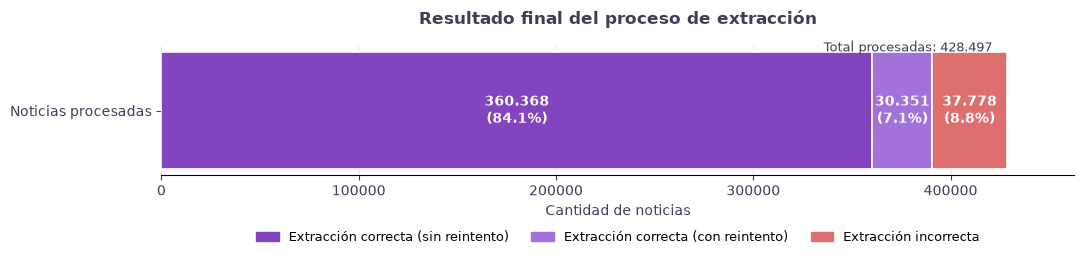

In [9]:
success_direct = total_valid - recovered_retry

plot_df = pd.DataFrame({
    "Componente": [
        "Extracción correcta (sin reintento)",
        "Extracción correcta (con reintento)",
        "Extracción incorrecta",
    ],
    "Cantidad": [
        success_direct,
        recovered_retry,
        total_invalid,
    ],
    "Color": [
        COLORS["violet_500"],
        COLORS["violet_400"],
        COLORS["secondary_300"],
    ]
})


def fmt_int(x):
    return f"{int(x):,}".replace(",", ".")


fig, ax = plt.subplots(figsize=(11, 2.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

left = 0
bars = []

for _, row in plot_df.iterrows():
    bar = ax.barh(
        ["Noticias procesadas"],
        [row["Cantidad"]],
        left=left,
        color=row["Color"],
        edgecolor="white",
        linewidth=1.2,
        height=0.4
    )
    bars.append((bar[0], row))
    left += row["Cantidad"]

# Etiquetas centradas dentro de cada segmento
for bar, row in bars:
    value = row["Cantidad"]
    pct = 100 * value / processed_total
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + bar.get_height() / 2
    width = bar.get_width()

    ax.text(
        x, y,
        f"{fmt_int(value)}\n({pct:.1f}%)",
        va="center",
        ha="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

ax.set_title(
    "Resultado final del proceso de extracción",
    fontsize=12,
    color=COLORS["text"],
    pad=16,
    fontweight="bold"
)

ax.set_xlabel("Cantidad de noticias", fontsize=10, color=COLORS["text"])
ax.set_ylabel("")
ax.tick_params(axis="x", colors=COLORS["text"], labelsize=10)
ax.tick_params(axis="y", colors=COLORS["text"], labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)

# Ajustar límites para que el texto del total no choque
ax.set_xlim(0, processed_total * 1.08)

# Total procesadas: arriba de la barra, alineado a la derecha
ax.text(
    0.91,
    0.99,
    f"Total procesadas: {fmt_int(processed_total)}",
    transform=ax.transAxes,
    ha="right",
    va="center",
    fontsize=9,
    color=COLORS["text"]
)

# Etiquetas algo más breves para la leyenda
legend_labels = [
    "Extracción correcta (sin reintento)",
    "Extracción correcta (con reintento)",
    "Extracción incorrecta",
]

legend_handles = [
    plt.Rectangle(
        (0, 0), 1, 1,
        color=plot_df.iloc[i]["Color"]
    )
    for i in range(len(plot_df))
]

ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=3,
    frameon=False,
    fontsize=9,
    handlelength=1.8,
    columnspacing=1.8
)

# Espacio suficiente para xlabel + leyenda
fig.subplots_adjust(
    left=0.15,
    right=0.98,
    top=0.82,
    bottom=0.36
)

plt.show()

La distribución obtenida confirma que la estrategia basada en capturas periódicas de páginas de entrada permitió recuperar de forma sistemática un volumen considerable de contenidos a lo largo del periodo analizado y para las distintas fuentes. El resultado es especialmente relevante desde el punto de vista metodológico, ya que muestra que fue posible sustituir una estrategia de recuperación directa poco escalable por un procedimiento de adquisición más eficiente, manteniendo una cobertura temporal y documental adecuada para los objetivos del estudio. La estrategia desarrollada permitió, por tanto, superar una de las principales limitaciones técnicas identificadas durante la construcción del corpus sin requerir infraestructura computacional adicional.

### 4.1 Cobertura observada por año, país y periódico

In [10]:
RUN_PATTERN = re.compile(r"(20\d{2})_(0[1-9]|1[0-2])")
article_files = sorted(RUNS_DIR.glob("**/articles_text.parquet"))

if not article_files:
    raise FileNotFoundError(
        f"No se encontraron articles_text.parquet bajo {RUNS_DIR}"
    )

records = []

for path in article_files:
    match = RUN_PATTERN.search(str(path))
    if match is None:
        continue

    year = int(match.group(1))
    month = int(match.group(2))

    df = pd.read_parquet(
        path,
        columns=["source", "text", "fetch_error"]
    )

    valid = (
        nonempty_text_mask(df)
        & no_fetch_error_mask(df)
    )

    tmp = df.assign(_valid_extraction=valid)

    counts = (
        tmp.groupby("source", as_index=False)
        .agg(
            n_processed=("source", "size"),
            n_valid=("_valid_extraction", "sum"),
        )
    )

    counts["n_failed"] = (
        counts["n_processed"] - counts["n_valid"]
    )
    counts["year"] = year
    counts["month"] = month
    counts["run_path"] = str(path.relative_to(ROOT))
    records.append(counts)

if not records:
    raise RuntimeError(
        "Se encontraron archivos, pero ninguno coincidió con el patrón YYYY_MM."
    )

extraction_by_run = pd.concat(records, ignore_index=True)
extraction_by_run = add_source_labels(extraction_by_run)

display(extraction_by_run.head())

,source,n_processed,n_valid,n_failed,year,month,run_path,country,newspaper
0,clarin_arg,876,856,20,2015,1,data\runs\2015_01\extracted_text\articles_text...,Argentina,Clarín
1,eluniversal_mx,1741,1432,309,2015,1,data\runs\2015_01\extracted_text\articles_text...,México,El Universal
2,lanacion,3,2,1,2015,1,data\runs\2015_01\extracted_text\articles_text...,Argentina,La Nación
3,milenio,1717,1673,44,2015,1,data\runs\2015_01\extracted_text\articles_text...,México,Milenio
4,pagina12,301,295,6,2015,1,data\runs\2015_01\extracted_text\articles_text...,Argentina,Página/12


In [11]:
coverage_by_year_source = (
    extraction_by_run
    .groupby(
        ["year", "country", "source", "newspaper"],
        as_index=False
    )
    .agg(
        Noticias_observadas=("n_processed", "sum"),
        Noticias_con_texto_valido=("n_valid", "sum"),
        Extracciones_fallidas=("n_failed", "sum"),
    )
)

coverage_by_year_source["Tasa_extraccion_pct"] = (
    100
    * coverage_by_year_source["Noticias_con_texto_valido"]
    / coverage_by_year_source["Noticias_observadas"]
)

display(coverage_by_year_source)

,year,country,source,newspaper,Noticias_observadas,Noticias_con_texto_valido,Extracciones_fallidas,Tasa_extraccion_pct
0,2015,Argentina,clarin_arg,Clarín,7491,7203,288,96.16
1,2015,Argentina,lanacion,La Nación,27,18,9,66.67
2,2015,Argentina,pagina12,Página/12,4634,4336,298,93.57
3,2015,México,eluniversal_mx,El Universal,6411,4511,1900,70.36
4,2015,México,jornada,La Jornada,21,14,7,66.67
5,2015,México,milenio,Milenio,17279,14777,2502,85.52
6,2016,Argentina,clarin_arg,Clarín,13841,13404,437,96.84
7,2016,Argentina,lanacion,La Nación,6,6,0,100.00
8,2016,Argentina,pagina12,Página/12,10560,9818,742,92.97
9,2016,México,jornada,La Jornada,204,35,169,17.16


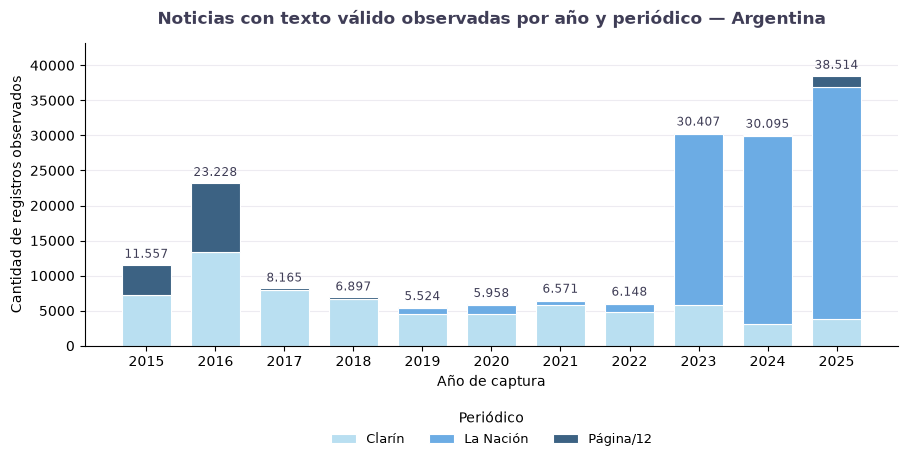

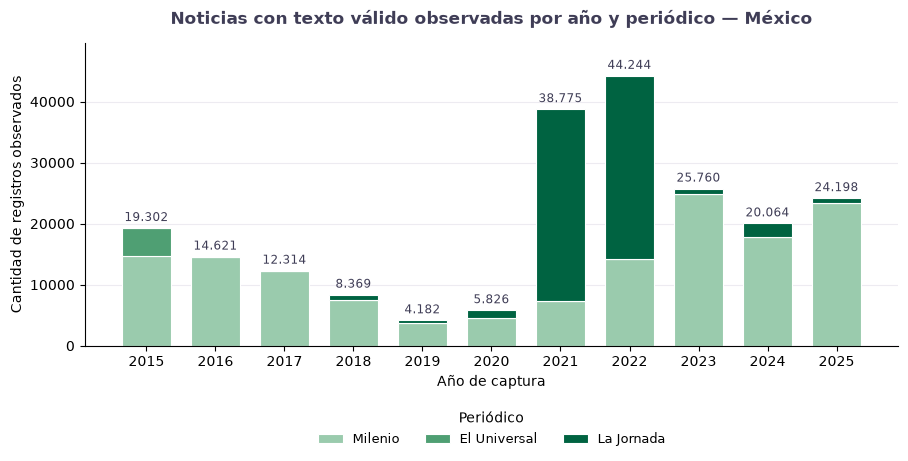

In [12]:
def plot_stacked_sources_by_year(data, country):
    subset = data.loc[
        data["country"].eq(country)
    ].copy()

    table = (
        subset.pivot_table(
            index="year",
            columns="newspaper",
            values="Noticias_con_texto_valido",
            aggfunc="sum",
            fill_value=0,
        )
        .sort_index()
    )

    newspapers = [
        n for n in SOURCE_ORDER[country]
        if n in table.columns
    ]
    table = table.reindex(columns=newspapers, fill_value=0)

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    bottom = np.zeros(len(table))

    for newspaper, color in zip(
        newspapers,
        SOURCE_COLORS[country]
    ):
        values = table[newspaper].to_numpy()
        ax.bar(
            table.index.astype(str),
            values,
            bottom=bottom,
            label=newspaper,
            color=color,
            width=0.72,
            edgecolor="white",
            linewidth=0.8,
        )
        bottom += values

    max_total = bottom.max() if len(bottom) else 0

    for i, total in enumerate(bottom):
        if total > 0:
            ax.text(
                i,
                total + max_total * 0.015,
                fmt_int(total),
                ha="center",
                va="bottom",
                fontsize=8.5,
                color=COLORS["text"],
            )

    ax.set_title(
        f"Noticias con texto válido observadas por año y periódico — {country}",
        fontsize=12,
        fontweight="bold",
        color=COLORS["text"],
        pad=14,
    )
    ax.set_xlabel("Año de captura")
    ax.set_ylabel("Cantidad de registros observados")
    ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if max_total > 0:
        ax.set_ylim(0, max_total * 1.12)

    ax.legend(
        title="Periódico",
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        frameon=False,
        fontsize=9,
    )
    fig.subplots_adjust(bottom=0.25)
    plt.show()


plot_stacked_sources_by_year(
    coverage_by_year_source,
    "Argentina"
)

plot_stacked_sources_by_year(
    coverage_by_year_source,
    "México"
)

### 4.2 Comparación conjunta por país, año y periódico

La siguiente figura presenta en un único gráfico las noticias con texto válido disponibles antes de la selección temática. Cada barra corresponde a un país y año, y su composición interna muestra la contribución de cada periódico.


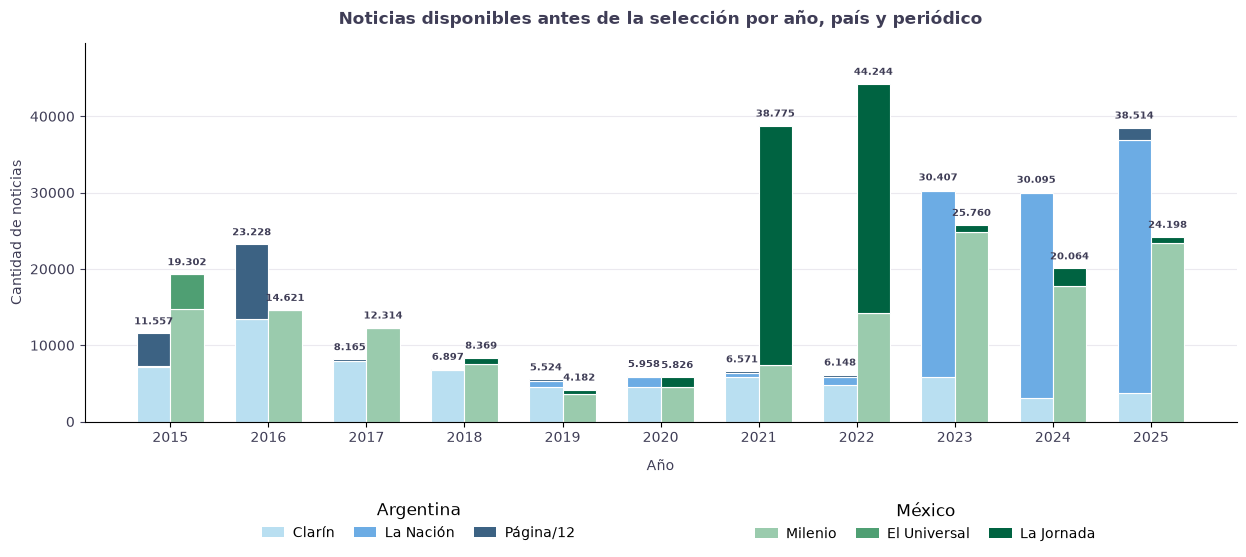

In [13]:
def plot_sources_by_country_year(data):
    data = data.copy()

    years = sorted(
        data["year"]
        .dropna()
        .unique()
    )

    x = np.arange(len(years))
    width = 0.34

    fig, ax = plt.subplots(figsize=(12.8, 6.2))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # ======================================================
    # ARGENTINA
    # ======================================================
    arg = (
        data[data["country"] == "Argentina"]
        .pivot_table(
            index="year",
            columns="newspaper",
            values="Noticias_con_texto_valido",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(years, fill_value=0)
    )

    for col in SOURCE_ORDER["Argentina"]:
        if col not in arg.columns:
            arg[col] = 0

    arg = arg[SOURCE_ORDER["Argentina"]]
    arg_bottom = np.zeros(len(years))

    for newspaper, color in zip(
        SOURCE_ORDER["Argentina"],
        SOURCE_COLORS["Argentina"],
    ):
        values = arg[newspaper].to_numpy()

        ax.bar(
            x - width / 2,
            values,
            width=width,
            bottom=arg_bottom,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=2,
        )

        arg_bottom += values

    # ======================================================
    # MÉXICO
    # ======================================================
    mx = (
        data[data["country"] == "México"]
        .pivot_table(
            index="year",
            columns="newspaper",
            values="Noticias_con_texto_valido",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(years, fill_value=0)
    )

    for col in SOURCE_ORDER["México"]:
        if col not in mx.columns:
            mx[col] = 0

    mx = mx[SOURCE_ORDER["México"]]
    mx_bottom = np.zeros(len(years))

    for newspaper, color in zip(
        SOURCE_ORDER["México"],
        SOURCE_COLORS["México"],
    ):
        values = mx[newspaper].to_numpy()

        ax.bar(
            x + width / 2,
            values,
            width=width,
            bottom=mx_bottom,
            color=color,
            edgecolor="white",
            linewidth=0.8,
            zorder=2,
        )

        mx_bottom += values

    # ======================================================
    # TOTALES POR PAÍS Y AÑO
    # ======================================================
    max_country_total = max(
        arg_bottom.max() if len(arg_bottom) else 0,
        mx_bottom.max() if len(mx_bottom) else 0,
    )

    offset = max_country_total * 0.02 if max_country_total > 0 else 1

    for i in range(len(years)):
        if arg_bottom[i] > 0:
            ax.text(
                x[i] - width / 2,
                arg_bottom[i] + offset,
                fmt_int(arg_bottom[i]),
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color=COLORS["text"],
            )

        if mx_bottom[i] > 0:
            ax.text(
                x[i] + width / 2,
                mx_bottom[i] + offset,
                fmt_int(mx_bottom[i]),
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color=COLORS["text"],
            )

    if max_country_total > 0:
        ax.set_ylim(0, max_country_total * 1.12)

    # ======================================================
    # ESTILO GENERAL
    # ======================================================
    ax.set_title(
        "Noticias disponibles antes de la selección por año, país y periódico",
        fontsize=12,
        fontweight="bold",
        color=COLORS["text"],
        pad=14,
    )

    ax.set_xlabel(
        "Año",
        fontsize=10,
        color=COLORS["text"],
        labelpad=10,
    )

    ax.set_ylabel(
        "Cantidad de noticias",
        fontsize=10,
        color=COLORS["text"],
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        years,
        fontsize=10,
        color=COLORS["text"],
    )

    ax.tick_params(
        axis="y",
        labelsize=10,
        colors=COLORS["text"],
    )

    ax.grid(
        axis="y",
        color=COLORS["grid"],
        linewidth=0.8,
        alpha=0.9,
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ======================================================
    # LEYENDAS
    # ======================================================
    arg_handles = [
        Patch(
            facecolor=color,
            edgecolor="none",
            label=label,
        )
        for color, label in zip(
            SOURCE_COLORS["Argentina"],
            SOURCE_ORDER["Argentina"],
        )
    ]

    mx_handles = [
        Patch(
            facecolor=color,
            edgecolor="none",
            label=label,
        )
        for color, label in zip(
            SOURCE_COLORS["México"],
            SOURCE_ORDER["México"],
        )
    ]

    leg1 = ax.legend(
        handles=arg_handles,
        title="Argentina",
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.29, -0.18),
        frameon=False,
        fontsize=10,
        title_fontsize=12,
        handlelength=1.6,
        handletextpad=0.6,
        columnspacing=1.4,
    )

    ax.add_artist(leg1)

    ax.legend(
        handles=mx_handles,
        title="México",
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.73, -0.18),
        frameon=False,
        fontsize=10,
        title_fontsize=12,
        handlelength=1.6,
        handletextpad=0.6,
        columnspacing=1.4,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.88,
        bottom=0.27,
    )

    plt.show()


plot_sources_by_country_year(coverage_by_year_source)

## 5. Universo único evaluable y preselección temática

A partir de aquí el denominador deja de ser el volumen bruto de `data/runs/`.  
Se usa el conjunto **único**, con texto válido y sin error final de descarga, contenido en `articles_contextual_unique.parquet`.

In [14]:
assert_columns(
    contextual_cases,
    ["text", "analysis_case_candidate", "provisional_case_status"],
    "contextual_cases",
)

contextual_valid = contextual_cases.loc[
    nonempty_text_mask(contextual_cases)
    & no_fetch_error_mask(contextual_cases)
].copy()

preselected_cases = contextual_valid.loc[
    contextual_valid["analysis_case_candidate"]
    .fillna(False)
    .astype(bool)
].copy()

preselected_cases["status_label"] = (
    preselected_cases["provisional_case_status"]
    .map(STATUS_LABELS)
    .fillna(preselected_cases["provisional_case_status"])
)

total_evaluable = len(contextual_valid)
total_preselected = len(preselected_cases)
total_not_preselected = total_evaluable - total_preselected

preselection_split = pd.DataFrame({
    "Grupo": ["Preseleccionadas", "No preseleccionadas"],
    "Noticias": [total_preselected, total_not_preselected],
})

preselection_split["Porcentaje"] = (
    100
    * preselection_split["Noticias"]
    / total_evaluable
)

display(preselection_split)

print(
    f"Tasa global de preselección: "
    f"{safe_rate(total_preselected, total_evaluable):.2f}%"
)

,Grupo,Noticias,Porcentaje
0,Preseleccionadas,5324,1.43
1,No preseleccionadas,366741,98.57


Tasa global de preselección: 1.43%


,Categoría,Noticias,Porcentaje
0,Caso explícito candidato,3155,59.26
1,Caso ambiguo,1631,30.63
2,Contextual de alta confianza,342,6.42
3,Contextual de sensibilidad media,196,3.68


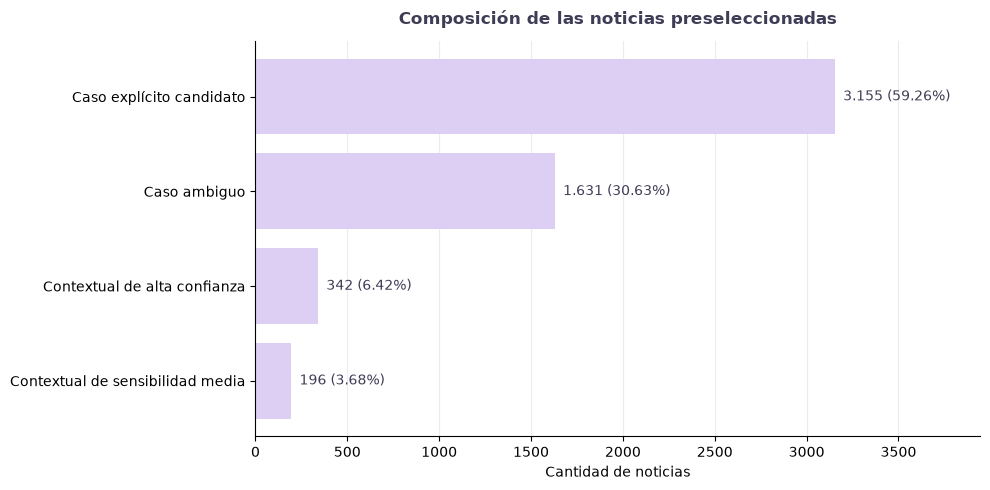

In [15]:
preselection_status = (
    preselected_cases["status_label"]
    .value_counts(dropna=False)
    .rename_axis("Categoría")
    .reset_index(name="Noticias")
)

preselection_status["Porcentaje"] = (
    100
    * preselection_status["Noticias"]
    / preselection_status["Noticias"].sum()
)

display(preselection_status)

plot_data = preselection_status.sort_values("Noticias")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    plot_data["Categoría"],
    plot_data["Noticias"],
    color=COLORS["violet_200"],
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {fmt_int(row['Noticias'])} ({row['Porcentaje']:.2f}%)",
        va="center",
        fontsize=10,
        color=COLORS["text"],
    )

ax.set_title(
    "Composición de las noticias preseleccionadas",
    fontsize=12,
    fontweight="bold",
    color=COLORS["text"],
    pad=12,
)
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, plot_data["Noticias"].max() * 1.25)
plt.tight_layout()
plt.show()

### 5.1 Tasa de preselección por país y periódico

In [16]:
def selection_rate_table(
    universe,
    selected,
    group_cols,
    rate_name="Tasa_preseleccion_pct",
):
    evaluated = (
        universe.groupby(group_cols, as_index=False)
        .size()
        .rename(columns={"size": "Noticias_evaluadas"})
    )

    selected_counts = (
        selected.groupby(group_cols, as_index=False)
        .size()
        .rename(columns={"size": "Noticias_preseleccionadas"})
    )

    out = evaluated.merge(
        selected_counts,
        on=group_cols,
        how="left",
    )

    out["Noticias_preseleccionadas"] = (
        out["Noticias_preseleccionadas"]
        .fillna(0)
        .astype(int)
    )

    out[rate_name] = (
        100
        * out["Noticias_preseleccionadas"]
        / out["Noticias_evaluadas"]
    )
    return out


preselection_country = selection_rate_table(
    contextual_valid,
    preselected_cases,
    ["country"],
)

preselection_newspaper = selection_rate_table(
    contextual_valid,
    preselected_cases,
    ["country", "source", "newspaper"],
)

display(preselection_country)
display(preselection_newspaper)

,country,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct
0,Argentina,166061,2108,1.27
1,México,206004,3216,1.56


,country,source,newspaper,Noticias_evaluadas,Noticias_preseleccionadas,Tasa_preseleccion_pct
0,Argentina,clarin_arg,Clarín,66157,1159,1.75
1,Argentina,lanacion,La Nación,84153,715,0.85
2,Argentina,pagina12,Página/12,15751,234,1.49
3,México,eluniversal_mx,El Universal,4446,20,0.45
4,México,jornada,La Jornada,65466,1281,1.96
5,México,milenio,Milenio,136092,1915,1.41


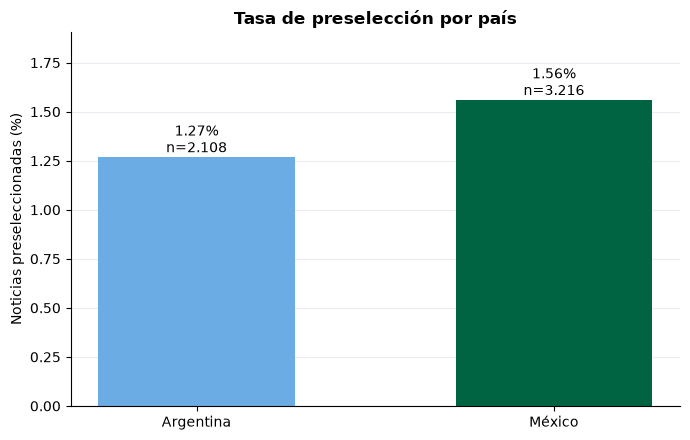

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))

country_colors = [
    COLORS["argentina"]
    if country == "Argentina"
    else COLORS["mexico_dark"]
    for country in preselection_country["country"]
]

bars = ax.bar(
    preselection_country["country"],
    preselection_country["Tasa_preseleccion_pct"],
    color=country_colors,
    width=0.55,
)

for bar, (_, row) in zip(
    bars,
    preselection_country.iterrows()
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        (
            f"{row['Tasa_preseleccion_pct']:.2f}%\n"
            f"n={fmt_int(row['Noticias_preseleccionadas'])}"
        ),
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_title("Tasa de preselección por país", fontweight="bold")
ax.set_ylabel("Noticias preseleccionadas (%)")
ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(
    0,
    preselection_country["Tasa_preseleccion_pct"].max() * 1.22
)
plt.tight_layout()
plt.show()

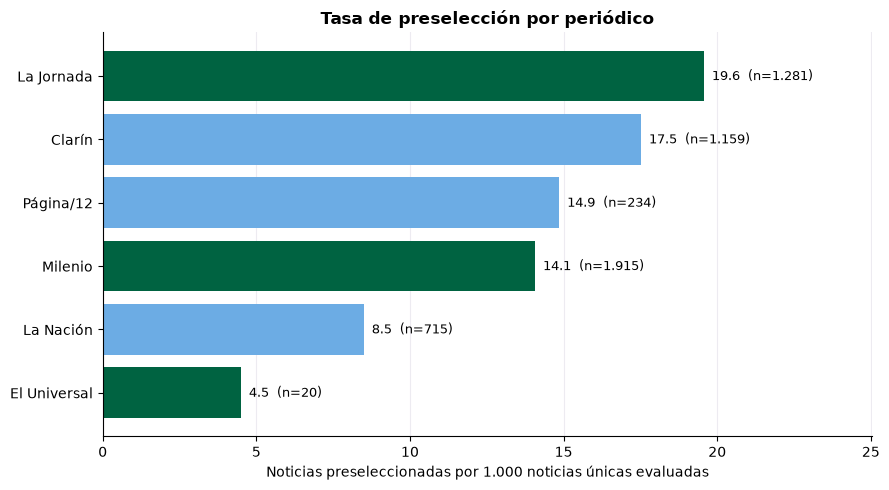

In [18]:
plot_data = preselection_newspaper.copy()
plot_data["Preseleccionadas_por_1000"] = (
    1000
    * plot_data["Noticias_preseleccionadas"]
    / plot_data["Noticias_evaluadas"]
)
plot_data = plot_data.sort_values("Preseleccionadas_por_1000")

bar_colors = [
    COLORS["argentina"]
    if country == "Argentina"
    else COLORS["mexico_dark"]
    for country in plot_data["country"]
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    plot_data["newspaper"],
    plot_data["Preseleccionadas_por_1000"],
    color=bar_colors,
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        (
            f"  {row['Preseleccionadas_por_1000']:.1f}"
            f"  (n={fmt_int(row['Noticias_preseleccionadas'])})"
        ),
        va="center",
        fontsize=9,
    )

ax.set_title("Tasa de preselección por periódico", fontweight="bold")
ax.set_xlabel(
    "Noticias preseleccionadas por 1.000 noticias únicas evaluadas"
)
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(
    0,
    plot_data["Preseleccionadas_por_1000"].max() * 1.28
)
plt.tight_layout()
plt.show()

### 5.2 Proporción de candidatos sobre noticias recuperadas por medio

In [19]:
# ==========================================================
# Gráfico: proporción de candidatos sobre noticias recuperadas
# ==========================================================

def infer_year_column(df):
    for col in ["archive_year", "year"]:
        if col in df.columns:
            return col
    raise KeyError(
        "No se encontró una columna de año ('archive_year' o 'year').")


def infer_source_column(df):
    for col in ["newspaper", "source", "medio"]:
        if col in df.columns:
            return col
    raise KeyError(
        "No se encontró una columna de medio ('newspaper', 'source' o 'medio').")


def choose_doc_key_for_plot(*dfs):
    candidates = [
        ["normalized_url", "archive_year"],
        ["normalized_url"],
        ["candidate_url", "archive_year"],
        ["candidate_url"],
        ["url", "archive_year"],
        ["url"],
    ]

    for key in candidates:
        ok = True
        for df in dfs:
            if not all(col in df.columns for col in key):
                ok = False
                break
            if not df[key].notna().all(axis=1).all():
                ok = False
                break
        if ok:
            return key

    raise KeyError("No se encontró una clave documental común y completa.")


YEAR_COL = infer_year_column(contextual_valid)
SOURCE_COL = infer_source_column(contextual_valid)
DOC_KEY_PLOT = choose_doc_key_for_plot(contextual_valid, preselected_cases)

# Noticias recuperadas con texto válido
recovered_by_source_year = (
    contextual_valid
    .dropna(subset=[YEAR_COL, SOURCE_COL])
    .groupby([YEAR_COL, SOURCE_COL], as_index=False)
    .size()
    .rename(columns={"size": "Noticias_recuperadas"})
)

# Candidatos únicos
preselected_unique = (
    preselected_cases
    .drop_duplicates(subset=DOC_KEY_PLOT)
    .copy()
)

candidates_by_source_year = (
    preselected_unique
    .dropna(subset=[YEAR_COL, SOURCE_COL])
    .groupby([YEAR_COL, SOURCE_COL], as_index=False)
    .size()
    .rename(columns={"size": "Candidatos"})
)

candidate_rate = (
    recovered_by_source_year
    .merge(
        candidates_by_source_year,
        on=[YEAR_COL, SOURCE_COL],
        how="left"
    )
    .fillna({"Candidatos": 0})
)

candidate_rate["Candidatos"] = candidate_rate["Candidatos"].astype(int)
candidate_rate["Candidatos_por_100"] = (
    100 * candidate_rate["Candidatos"] / candidate_rate["Noticias_recuperadas"]
)

display(candidate_rate.head())

,archive_year,newspaper,Noticias_recuperadas,Candidatos,Candidatos_por_100
0,2015,Clarín,7176,155,2.16
1,2015,El Universal,4446,20,0.45
2,2015,La Jornada,5,1,20.00
3,2015,La Nación,2,0,0.00
4,2015,Milenio,14516,126,0.87


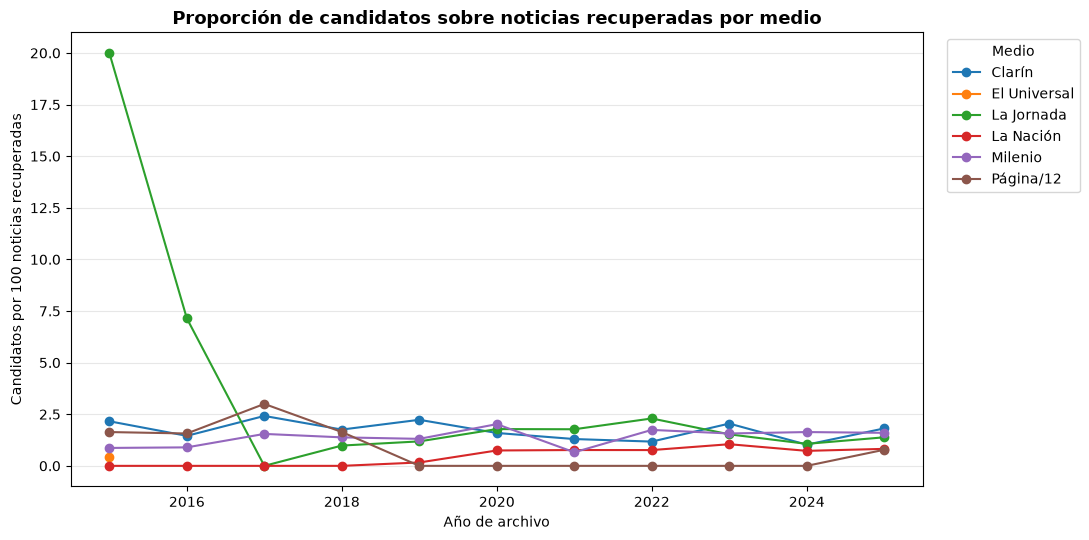

In [20]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for source, group in candidate_rate.groupby(SOURCE_COL):
    group = group.sort_values(YEAR_COL)
    ax.plot(
        group[YEAR_COL],
        group["Candidatos_por_100"],
        marker="o",
        label=source
    )

ax.set_title(
    "Proporción de candidatos sobre noticias recuperadas por medio",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Año de archivo")
ax.set_ylabel("Candidatos por 100 noticias recuperadas")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Medio", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Construcción del corpus principal

Se reconcilian las noticias preseleccionadas con los tres destinos generados por el pipeline:

- corpus principal;
- sensibilidad media;
- casos ambiguos.

Las noticias que no aparecen en ninguno de esos tres conjuntos se contabilizan como exclusiones durante la consolidación final.

In [21]:
def choose_document_key(*dfs):
    candidates = [
        ["normalized_url", "archive_year"],
        ["normalized_url"],
        ["candidate_url", "archive_year"],
        ["candidate_url"],
        ["url", "archive_year"],
        ["url"],
    ]

    for key in candidates:
        if all(all(col in df.columns for col in key) for df in dfs):
            return key

    raise KeyError(
        "No se encontró una clave documental común entre los datasets."
    )


DOC_KEY = choose_document_key(
    preselected_cases,
    main_cases,
    medium_cases,
    ambiguous_cases,
)

print("Clave documental usada:", DOC_KEY)


def key_frame(df, key):
    return df[key].dropna().drop_duplicates()


main_keys = key_frame(main_cases, DOC_KEY)
medium_keys = key_frame(medium_cases, DOC_KEY)
ambiguous_keys = key_frame(ambiguous_cases, DOC_KEY)

# Comprobar que los destinos finales no se solapan.


def key_tuples(df, key):
    return set(map(tuple, df[key].dropna().drop_duplicates().to_numpy()))


preselected_set = key_tuples(preselected_cases, DOC_KEY)
main_set = key_tuples(main_cases, DOC_KEY)
medium_set = key_tuples(medium_cases, DOC_KEY)
ambiguous_set = key_tuples(ambiguous_cases, DOC_KEY)

assert main_set.isdisjoint(medium_set)
assert main_set.isdisjoint(ambiguous_set)
assert medium_set.isdisjoint(ambiguous_set)

final_keys = pd.concat(
    [main_keys, medium_keys, ambiguous_keys],
    ignore_index=True,
).drop_duplicates()

main_from_preselection = main_set & preselected_set
medium_from_preselection = medium_set & preselected_set
ambiguous_from_preselection = ambiguous_set & preselected_set

missing_from_final_set = (
    preselected_set
    - (main_set | medium_set | ambiguous_set)
)

_missing_keys = (
    preselected_cases[DOC_KEY]
    .apply(tuple, axis=1)
)

missing_from_final = (
    preselected_cases.loc[
        _missing_keys.isin(missing_from_final_set)
    ]
    .drop_duplicates(subset=DOC_KEY)
    .copy()
)


final_selection_summary = pd.DataFrame({
    "Destino": [
        "Corpus principal",
        "Sensibilidad media",
        "Casos ambiguos",
        "No incorporadas al consolidado final",
    ],
    "Noticias": [
        len(main_from_preselection),
        len(medium_from_preselection),
        len(ambiguous_from_preselection),
        len(missing_from_final_set),
    ],
})

final_selection_summary["Porcentaje_sobre_preseleccionadas"] = (
    100
    * final_selection_summary["Noticias"]
    / len(preselected_cases)
)

display(final_selection_summary)

reconciled = final_selection_summary["Noticias"].sum()
print("Preseleccionadas:", fmt_int(len(preselected_cases)))
print("Destinos reconciliados:", fmt_int(reconciled))
print("Diferencia:", fmt_int(len(preselected_cases) - reconciled))

Clave documental usada: ['normalized_url', 'archive_year']


,Destino,Noticias,Porcentaje_sobre_preseleccionadas
0,Corpus principal,3475,65.27
1,Sensibilidad media,194,3.64
2,Casos ambiguos,1593,29.92
3,No incorporadas al consolidado final,62,1.16


Preseleccionadas: 5.324
Destinos reconciliados: 5.324
Diferencia: 0


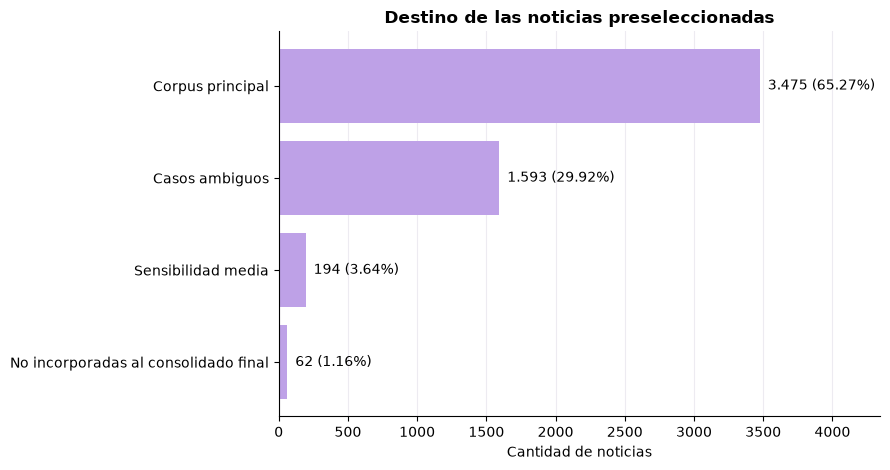

In [22]:
# La igualdad debe cumplirse si la misma definición documental se conserva
# en preselección y consolidación final.
assert final_selection_summary["Noticias"].sum() == len(preselected_set), (
    "La transición preselección → destinos finales no reconcilia. "
    "Revisa la clave documental o duplicados entre etapas."
)

plot_data = final_selection_summary.sort_values("Noticias")

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(
    plot_data["Destino"],
    plot_data["Noticias"],
    color=COLORS["violet_300"],
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        (
            f"  {fmt_int(row['Noticias'])} "
            f"({row['Porcentaje_sobre_preseleccionadas']:.2f}%)"
        ),
        va="center",
        fontsize=10,
    )

ax.set_title(
    "Destino de las noticias preseleccionadas",
    fontweight="bold",
)
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, plot_data["Noticias"].max() * 1.25)
plt.tight_layout()
plt.show()

### 6.1 Auditoría de exclusiones

Este bloque es diagnóstico. No forma parte de los resultados sustantivos, pero permite verificar por qué ciertas noticias preseleccionadas quedaron fuera de los tres destinos finales.

In [23]:
audit_columns = [
    "provisional_case_status",
    "case_label",
    "topic_label",
    "gender_recognition_mode",
    "auto_scope_status",
    "auto_scope_reason",
    "manual_scope_decision",
]

audit_columns = [
    c for c in audit_columns
    if c in missing_from_final.columns
]

print("Exclusiones:", fmt_int(len(missing_from_final)))

for col in audit_columns:
    print("\n", "=" * 70)
    print(col)
    display(
        missing_from_final[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="Noticias")
    )

Exclusiones: 62

provisional_case_status


,provisional_case_status,Noticias
0,review_ambiguous_case,38
1,candidate_explicit_case,20
2,review_contextual_medium,2
3,candidate_contextual_high,2



case_label


,case_label,Noticias
0,weak_candidate,40
1,strong_candidate,17
2,review_candidate,3
3,not_candidate,2



topic_label


,topic_label,Noticias
0,not_candidate,42
1,strong_candidate,20



gender_recognition_mode


,gender_recognition_mode,Noticias
0,ambiguous_case_without_explicit_label,38
1,explicit_femicide_feminicide,16
2,contextual_without_explicit_label,4
3,explicit_gender_violence,4


## 7. Caracterización del corpus principal

A partir de esta sección los análisis se realizan sobre el corpus
analítico depurado (`case_articles_phase1.parquet`). El corpus principal
original se conserva en las secciones anteriores para reconstruir y
auditar la transición entre la preselección y los destinos finales.

In [24]:
assert_columns(
    analysis_cases,
    [
        "source",
        "gender_recognition_mode",
        "analysis_text",
    ],
    "analysis_cases",
)

analysis_cases = analysis_cases.copy()

analysis_cases["final_category"] = (
    analysis_cases["gender_recognition_mode"]
    .map(FINAL_CATEGORY_LABELS)
)

unmapped = (
    analysis_cases.loc[
        analysis_cases["final_category"].isna(),
        "gender_recognition_mode"
    ]
    .value_counts(dropna=False)
)

if len(unmapped):
    raise ValueError(
        "Hay valores de gender_recognition_mode sin mapear:\n"
        + unmapped.to_string()
    )

final_corpus_composition = (
    analysis_cases["final_category"]
    .value_counts()
    .reindex(
        FINAL_CATEGORY_ORDER,
        fill_value=0,
    )
    .rename_axis("Categoría")
    .reset_index(name="Noticias")
)

final_corpus_composition["Porcentaje"] = (
    100
    * final_corpus_composition["Noticias"]
    / len(analysis_cases)
)

display(final_corpus_composition)

assert (
    final_corpus_composition["Noticias"].sum()
    == len(analysis_cases)
)

,Categoría,Noticias,Porcentaje
0,Explícito,2945,86.62
1,Contextual high,338,9.94
2,Topic,117,3.44


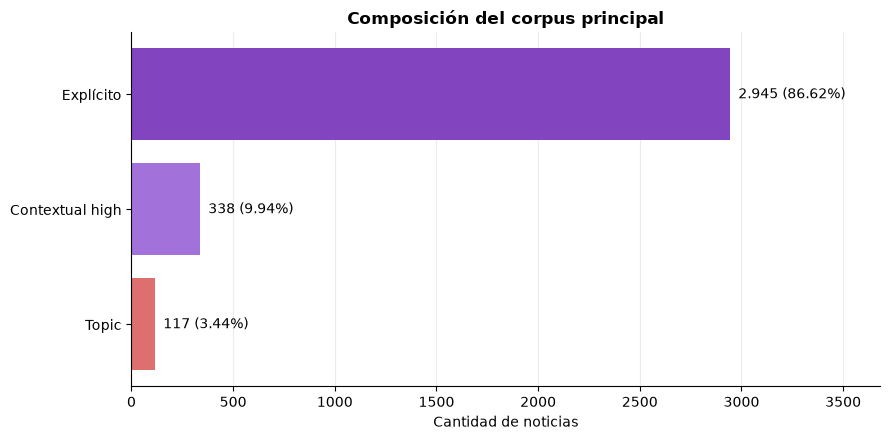

In [25]:
plot_data = final_corpus_composition.sort_values("Noticias")

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(
    plot_data["Categoría"],
    plot_data["Noticias"],
    color=[
        CATEGORY_COLORS[c]
        for c in plot_data["Categoría"]
    ],
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {fmt_int(row['Noticias'])} ({row['Porcentaje']:.2f}%)",
        va="center",
        fontsize=10,
    )

ax.set_title("Composición del corpus principal", fontweight="bold")
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, plot_data["Noticias"].max() * 1.25)
plt.tight_layout()
plt.show()

### 7.1 Distribución por país, periódico y año

In [26]:
corpus_by_country = (
    analysis_cases.groupby("country", as_index=False)
    .size()
    .rename(columns={"size": "Noticias"})
)
corpus_by_country["Porcentaje"] = (
    100 * corpus_by_country["Noticias"] / len(analysis_cases)
)

corpus_by_newspaper = (
    analysis_cases.groupby(
        ["country", "newspaper"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Noticias"})
)
corpus_by_newspaper["Porcentaje"] = (
    100 * corpus_by_newspaper["Noticias"] / len(analysis_cases)
)

corpus_by_year_country_source = (
    analysis_cases.dropna(subset=["year"])
    .groupby(
        ["year", "country", "source", "newspaper"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Noticias"})
)

display(corpus_by_country)
display(corpus_by_newspaper)
display(corpus_by_year_country_source)

,country,Noticias,Porcentaje
0,Argentina,1196,35.18
1,México,2204,64.82


,country,newspaper,Noticias,Porcentaje
0,Argentina,Clarín,667,19.62
1,Argentina,La Nación,363,10.68
2,Argentina,Página/12,166,4.88
3,México,El Universal,4,0.12
4,México,La Jornada,1005,29.56
5,México,Milenio,1195,35.15


,year,country,source,newspaper,Noticias
0,2015,Argentina,clarin_arg,Clarín,65
1,2015,Argentina,pagina12,Página/12,46
2,2015,México,eluniversal_mx,El Universal,4
3,2015,México,milenio,Milenio,52
4,2016,Argentina,clarin_arg,Clarín,111
5,2016,Argentina,pagina12,Página/12,114
6,2016,México,milenio,Milenio,49
7,2017,Argentina,clarin_arg,Clarín,103
8,2017,México,milenio,Milenio,99
9,2018,Argentina,clarin_arg,Clarín,62


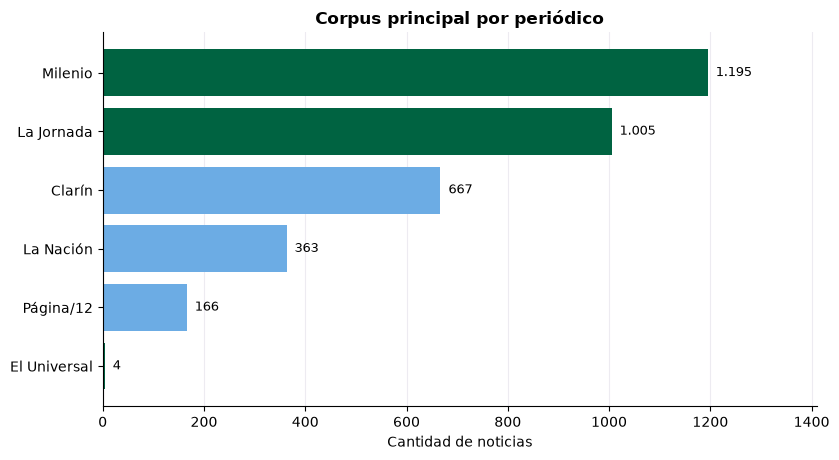

In [27]:
fig, ax = plt.subplots(figsize=(8.5, 4.7))

plot_data = corpus_by_newspaper.sort_values("Noticias")
bar_colors = [
    COLORS["argentina"]
    if c == "Argentina"
    else COLORS["mexico_dark"]
    for c in plot_data["country"]
]

bars = ax.barh(
    plot_data["newspaper"],
    plot_data["Noticias"],
    color=bar_colors,
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {fmt_int(row['Noticias'])}",
        va="center",
        fontsize=9,
    )

ax.set_title("Corpus principal por periódico", fontweight="bold")
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, plot_data["Noticias"].max() * 1.18)
plt.tight_layout()
plt.show()

### 7.2 Categorías del corpus principal por año y país

In [28]:
final_category_year_country = (
    analysis_cases
    .dropna(subset=["country", "year", "final_category"])
    .groupby(
        ["country", "year", "final_category"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Noticias"})
)

display(final_category_year_country)

,country,year,final_category,Noticias
0,Argentina,2015,Contextual high,26
1,Argentina,2015,Explícito,73
2,Argentina,2015,Topic,12
3,Argentina,2016,Contextual high,35
4,Argentina,2016,Explícito,176
5,Argentina,2016,Topic,14
6,Argentina,2017,Contextual high,16
7,Argentina,2017,Explícito,78
8,Argentina,2017,Topic,9
9,Argentina,2018,Contextual high,14


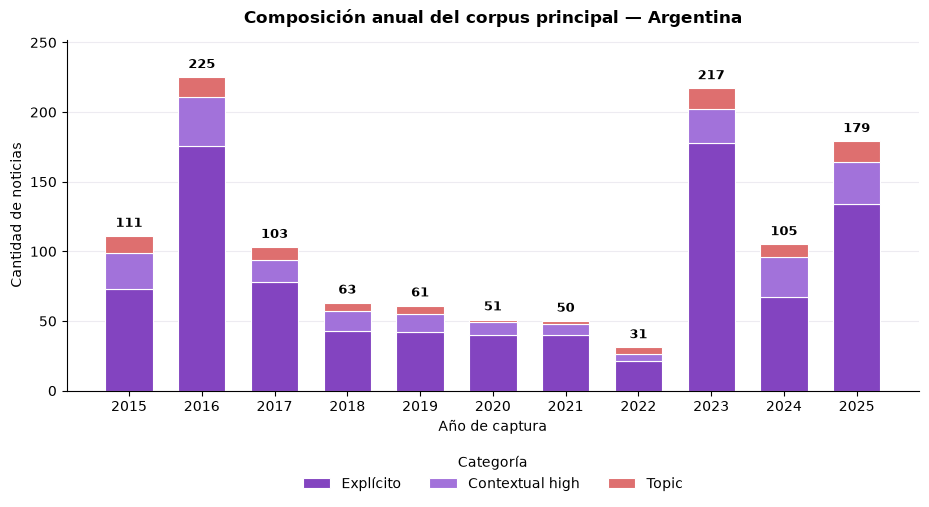

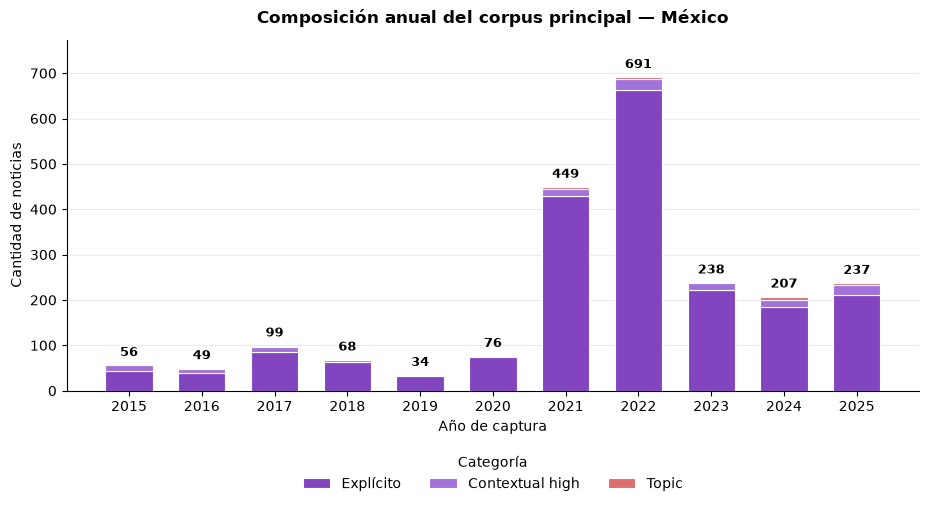

In [29]:
def plot_final_categories_by_year_country(df, country):
    country_data = (
        df.loc[df["country"].eq(country)]
        .pivot_table(
            index="year",
            columns="final_category",
            values="Noticias",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(
            columns=FINAL_CATEGORY_ORDER,
            fill_value=0,
        )
        .sort_index()
    )

    years = country_data.index.astype(int)
    fig, ax = plt.subplots(figsize=(11, 5.4))
    bottom = np.zeros(len(country_data))

    for category in FINAL_CATEGORY_ORDER:
        values = country_data[category].to_numpy()
        ax.bar(
            years,
            values,
            bottom=bottom,
            label=category,
            color=CATEGORY_COLORS[category],
            width=0.65,
            edgecolor="white",
            linewidth=0.8,
        )
        bottom += values

    max_total = bottom.max() if len(bottom) else 0
    offset = max_total * 0.02

    for year, total in zip(years, bottom):
        if total > 0:
            ax.text(
                year,
                total + offset,
                fmt_int(total),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    ax.set_title(
        f"Composición anual del corpus principal — {country}",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Año de captura")
    ax.set_ylabel("Cantidad de noticias")
    ax.set_xticks(years)
    ax.grid(axis="y", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if max_total > 0:
        ax.set_ylim(0, max_total * 1.12)

    ax.legend(
        title="Categoría",
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
    )
    fig.subplots_adjust(bottom=0.23)
    plt.show()


plot_final_categories_by_year_country(
    final_category_year_country,
    "Argentina"
)

plot_final_categories_by_year_country(
    final_category_year_country,
    "México"
)

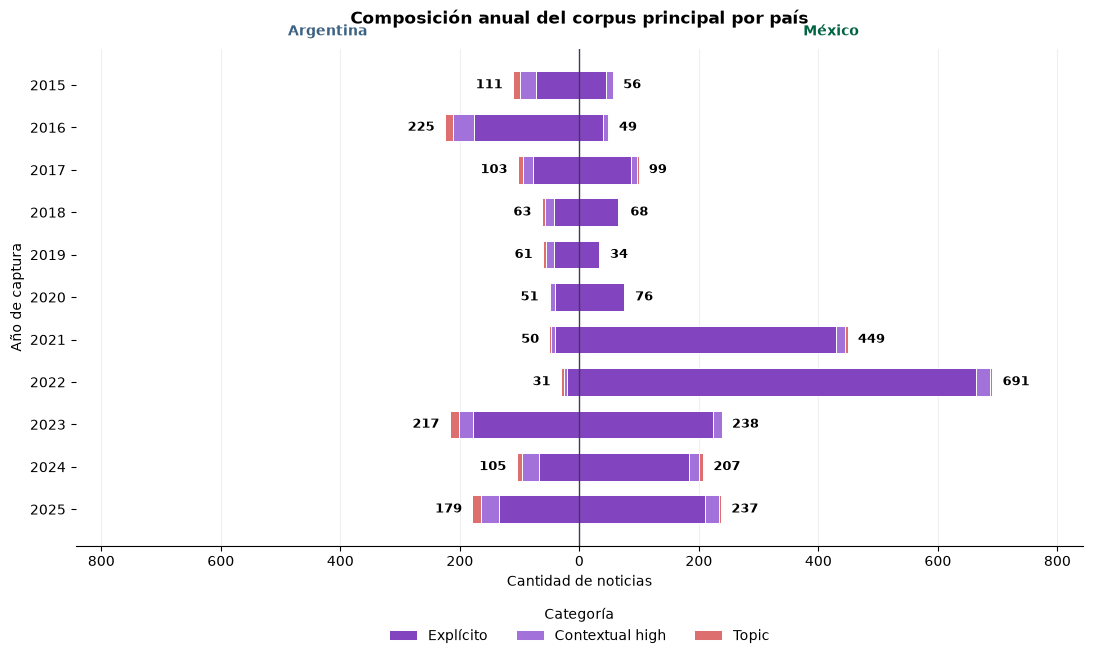

In [30]:
# Back-to-back Argentina vs México.
plot_base = (
    final_category_year_country
    .pivot_table(
        index=["country", "year"],
        columns="final_category",
        values="Noticias",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=FINAL_CATEGORY_ORDER, fill_value=0)
)

years = sorted(
    final_category_year_country["year"]
    .dropna()
    .astype(int)
    .unique()
)


def country_matrix(country):
    countries = plot_base.index.get_level_values("country")
    if country in countries:
        return (
            plot_base.loc[country]
            .reindex(years, fill_value=0)
        )
    return pd.DataFrame(
        0,
        index=years,
        columns=FINAL_CATEGORY_ORDER,
    )


arg = country_matrix("Argentina")
mx = country_matrix("México")

fig, ax = plt.subplots(figsize=(13, 7))
y = np.arange(len(years))

arg_left = np.zeros(len(years))
mx_left = np.zeros(len(years))

for category in FINAL_CATEGORY_ORDER:
    arg_values = arg[category].to_numpy()
    mx_values = mx[category].to_numpy()

    ax.barh(
        y,
        -arg_values,
        left=-arg_left,
        height=0.65,
        color=CATEGORY_COLORS[category],
        edgecolor="white",
        linewidth=0.7,
        label=category,
    )

    ax.barh(
        y,
        mx_values,
        left=mx_left,
        height=0.65,
        color=CATEGORY_COLORS[category],
        edgecolor="white",
        linewidth=0.7,
    )

    arg_left += arg_values
    mx_left += mx_values

max_total = max(
    arg_left.max() if len(arg_left) else 0,
    mx_left.max() if len(mx_left) else 0,
)
offset = max_total * 0.025 if max_total else 1

for i, (arg_total, mx_total) in enumerate(
    zip(arg_left, mx_left)
):
    if arg_total > 0:
        ax.text(
            -arg_total - offset,
            i,
            fmt_int(arg_total),
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

    if mx_total > 0:
        ax.text(
            mx_total + offset,
            i,
            fmt_int(mx_total),
            ha="left",
            va="center",
            fontsize=9,
            fontweight="bold",
        )

ax.axvline(0, color=COLORS["text"], linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(years)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: fmt_int(abs(x)))
)

if max_total > 0:
    limit = max_total * 1.22
    ax.set_xlim(-limit, limit)

ax.set_title(
    "Composición anual del corpus principal por país",
    fontsize=12,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Cantidad de noticias")
ax.set_ylabel("Año de captura")

ax.text(
    0.25, 1.02, "Argentina",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontweight="bold",
    color=COLORS["argentina_dark"],
)
ax.text(
    0.75, 1.02, "México",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontweight="bold",
    color=COLORS["mexico_dark"],
)

ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    title="Categoría",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False,
)

fig.subplots_adjust(bottom=0.17, top=0.88)
plt.show()

## 8. Calidad textual del corpus principal

Antes del análisis léxico se verifica que el corpus principal tenga texto utilizable y se describen longitudes documentales.  
Estas métricas sirven para detectar documentos anormalmente cortos y para justificar el universo textual usado en los análisis posteriores.

In [31]:
TEXT_COL = "analysis_text"

assert_columns(
    analysis_cases,
    [TEXT_COL],
    "analysis_cases",
)

# ==========================================================
# 1. CONTROL DE CODIFICACIÓN
# ==========================================================

bad_encoding_pattern = r"Ã|Â|â|�|Ì"

n_bad_encoding = (
    analysis_cases[TEXT_COL]
    .fillna("")
    .str.contains(
        bad_encoding_pattern,
        regex=True,
        na=False,
    )
    .sum()
)

if n_bad_encoding:
    raise ValueError(
        f"El corpus analítico contiene "
        f"{n_bad_encoding} textos con mojibake."
    )


# ==========================================================
# 2. FORMAS CORRUPTAS COMPROBADAS
# ==========================================================

BAD_CORPUS_TERMS = [
    "asà",
    "ahà",
    "mà",
    "Secretarìa",
    "ocurriò",
]

bad_counts = {}

for term in BAD_CORPUS_TERMS:

    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(term)}"
        rf"(?!\w)"
    )

    count = (
        analysis_cases[TEXT_COL]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
        .sum()
    )

    if count > 0:
        bad_counts[term] = int(count)


if bad_counts:
    raise ValueError(
        "Persisten formas corruptas "
        f"en el corpus: {bad_counts}"
    )

print("✓ Codificación del corpus validada.")


# ==========================================================
# 3. CALIDAD TEXTUAL
# ==========================================================

analysis_cases["has_text"] = (
    analysis_cases[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

analysis_cases["n_chars"] = (
    analysis_cases[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.len()
)

analysis_cases["n_words_raw"] = (
    analysis_cases[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.findall(r"\b\w+\b")
    .str.len()
)


text_quality = pd.DataFrame({
    "Indicador": [
        "Noticias del corpus analítico",
        "Noticias con texto no vacío",
        "Noticias sin texto",
        "Mediana de palabras",
        "Media de palabras",
        "Percentil 5 de palabras",
        "Percentil 95 de palabras",
    ],
    "Valor": [
        len(analysis_cases),

        int(
            analysis_cases["has_text"].sum()
        ),

        int(
            (~analysis_cases["has_text"]).sum()
        ),

        analysis_cases.loc[
            analysis_cases["has_text"],
            "n_words_raw"
        ].median(),

        analysis_cases.loc[
            analysis_cases["has_text"],
            "n_words_raw"
        ].mean(),

        analysis_cases.loc[
            analysis_cases["has_text"],
            "n_words_raw"
        ].quantile(0.05),

        analysis_cases.loc[
            analysis_cases["has_text"],
            "n_words_raw"
        ].quantile(0.95),
    ],
})

display(text_quality)

✓ Codificación del corpus validada.


,Indicador,Valor
0,Noticias del corpus analítico,"3,400.00"
1,Noticias con texto no vacío,"3,400.00"
2,Noticias sin texto,0.00
3,Mediana de palabras,469.00
4,Media de palabras,584.74
5,Percentil 5 de palabras,185.00
6,Percentil 95 de palabras,"1,269.05"


In [32]:
mask_xico = (
    analysis_cases[TEXT_COL]
    .fillna("")
    .str.contains(
        r"(?<!\w)xico(?!\w)",
        case=False,
        regex=True,
        na=False,
    )
)

display(
    analysis_cases.loc[
        mask_xico,
        [
            "country",
            "source",
            "title",
            "candidate_url",
            TEXT_COL,
        ]
    ]
)

,country,source,title,candidate_url,analysis_text
835,México,jornada,,http://www.jornada.com.mx/2019/05/10/sociedad,"Son madres sin hijos. Desaparecidos, asesinado..."


In [33]:
import re

BAD_TERMS = [
    "xico",
    "nero",
    "ctimas",
    "asà",
    "ahà",
    "mà",
    "Secretarìa",
    "ocurriò",
]

print("Ruta del corpus:")
print(ANALYSIS_PATH.resolve())

print("\nNúmero de artículos:")
print(len(analysis_cases))

print("\nConteo exacto por forma sospechosa:")

for term in BAD_TERMS:

    pattern = rf"(?<!\w){re.escape(term)}(?!\w)"

    n = (
        analysis_cases[TEXT_COL]
        .fillna("")
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
        .sum()
    )

    print(f"{term:15s} {n}")

Ruta del corpus:
C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\outputs\final\case_articles_phase1.parquet

Número de artículos:
3400

Conteo exacto por forma sospechosa:
xico            1
nero            0
ctimas          0
asà             0
ahà             0
mà              0
Secretarìa      0
ocurriò         0


In [34]:
print(
    analysis_cases[
        [
            "has_text",
            "n_chars",
            "n_words_raw",
        ]
    ].head()
)

   has_text  n_chars  n_words_raw
0      True     3370          575
1      True     1655          293
2      True     2852          492
3      True      835          139
4      True     1822          292


In [35]:
text_quality_by_group = (
    analysis_cases.loc[
        analysis_cases["has_text"]
    ]
    .groupby(
        ["country", "newspaper"],
        as_index=False
    )
    .agg(
        Noticias=(TEXT_COL, "size"),
        Palabras_mediana=(
            "n_words_raw",
            "median",
        ),
        Palabras_media=(
            "n_words_raw",
            "mean",
        ),
        Palabras_p05=(
            "n_words_raw",
            lambda s: s.quantile(0.05),
        ),
        Palabras_p95=(
            "n_words_raw",
            lambda s: s.quantile(0.95),
        ),
    )
)

display(text_quality_by_group)

,country,newspaper,Noticias,Palabras_mediana,Palabras_media,Palabras_p05,Palabras_p95
0,Argentina,Clarín,667,575.00,690.72,277.60,"1,374.00"
1,Argentina,La Nación,363,754.00,872.34,387.80,"1,663.10"
2,Argentina,Página/12,166,786.00,863.72,203.75,"1,954.75"
3,México,El Universal,4,391.50,407.50,237.90,599.50
4,México,La Jornada,1005,383.00,408.85,132.40,776.80
5,México,Milenio,1195,428.00,548.00,186.40,"1,257.50"


Mediana aproximada de palabras por artículo y medio

In [36]:
# Solo letras Unicode.
# Evita limitar el corpus a ASCII + un pequeño conjunto
# manual de caracteres españoles.
TOKEN_RE = re.compile(
    r"[^\W\d_]{3,}",
    flags=re.UNICODE,
)


STOPWORDS_ES = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "dos", "el", "ella", "ellas", "ellos", "en", "entre", "era", "eran",
    "es", "esa", "esas", "ese", "eso", "esos", "esta", "estaba", "está",
    "están", "estas", "este", "esto", "estos", "fue", "fueron", "ha",
    "han", "hasta", "hay", "la", "las", "le", "les", "lo", "los", "más",
    "me", "mi", "mis", "muy", "no", "nos", "o", "otra", "otras", "otro",
    "otros", "para", "pero", "por", "porque", "que", "qué", "se", "ser",
    "si", "sí", "sin", "sobre", "son", "su", "sus", "también", "tiene",
    "tienen", "tras", "tu", "un", "una", "uno", "unos", "y", "ya",
}


def tokenize(text):
    tokens = TOKEN_RE.findall(
        str(text).lower()
    )

    return [
        token
        for token in tokens
        if token not in STOPWORDS_ES
    ]


def make_ngrams(tokens, n):
    if len(tokens) < n:
        return []

    return [
        " ".join(
            tokens[i:i + n]
        )
        for i in range(
            len(tokens) - n + 1
        )
    ]


lexical_cases = (
    analysis_cases.loc[
        analysis_cases["has_text"]
    ]
    .copy()
)


lexical_cases["tokens"] = (
    lexical_cases[TEXT_COL]
    .map(tokenize)
)

lexical_cases["n_tokens"] = (
    lexical_cases["tokens"]
    .map(len)
)


lexical_summary = (
    lexical_cases
    .groupby(
        "country",
        as_index=False
    )
    .agg(
        Noticias=("tokens", "size"),
        Tokens=("n_tokens", "sum"),
        Tokens_mediana=("n_tokens", "median"),
        Tokens_media=("n_tokens", "mean"),
    )
)

display(lexical_summary)

,country,Noticias,Tokens,Tokens_mediana,Tokens_media
0,Argentina,1196,468957,333.00,392.10
1,México,2204,548383,207.50,248.81


In [37]:
# ==========================================================
# Gráfico: mediana de palabras por artículo y medio
# ==========================================================

SOURCE_COL_LEX = infer_source_column(lexical_cases)

text_length_by_source = lexical_cases.copy()
text_length_by_source["n_palabras"] = (
    text_length_by_source[TEXT_COL]
    .fillna("")
    .str.split()
    .str.len()
)

median_words_by_source = (
    text_length_by_source
    .groupby(SOURCE_COL_LEX, as_index=False)["n_palabras"]
    .median()
    .rename(columns={"n_palabras": "Mediana_palabras"})
    .sort_values("Mediana_palabras", ascending=True)
)

display(median_words_by_source)

,newspaper,Mediana_palabras
2,La Jornada,385.00
1,El Universal,391.00
4,Milenio,428.00
0,Clarín,573.00
3,La Nación,752.00
5,Página/12,791.50


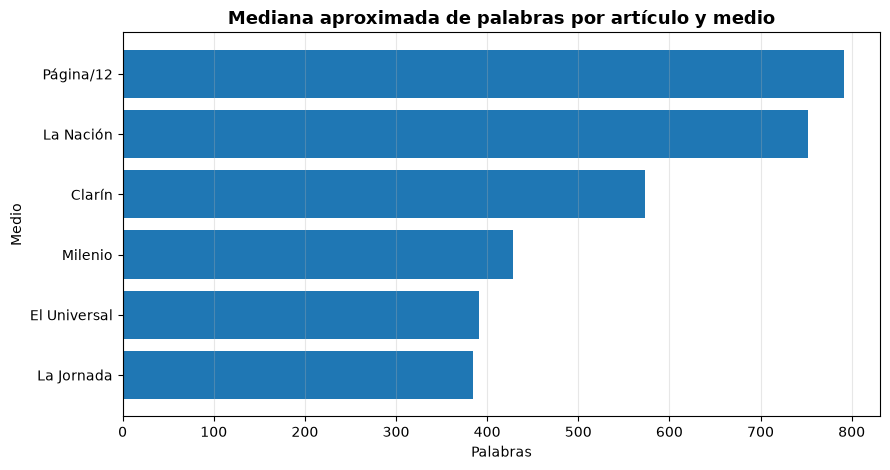

In [38]:
fig, ax = plt.subplots(figsize=(9, 4.8))

ax.barh(
    median_words_by_source[SOURCE_COL_LEX],
    median_words_by_source["Mediana_palabras"]
)

ax.set_title(
    "Mediana aproximada de palabras por artículo y medio",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Palabras")
ax.set_ylabel("Medio")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Distribución de longitud del texto analítico

count   3,400.00
mean      584.56
std       465.73
min        34.00
25%       342.00
50%       470.00
75%       692.50
90%     1,008.20
95%     1,271.00
max     9,622.00
Name: n_palabras, dtype: float64

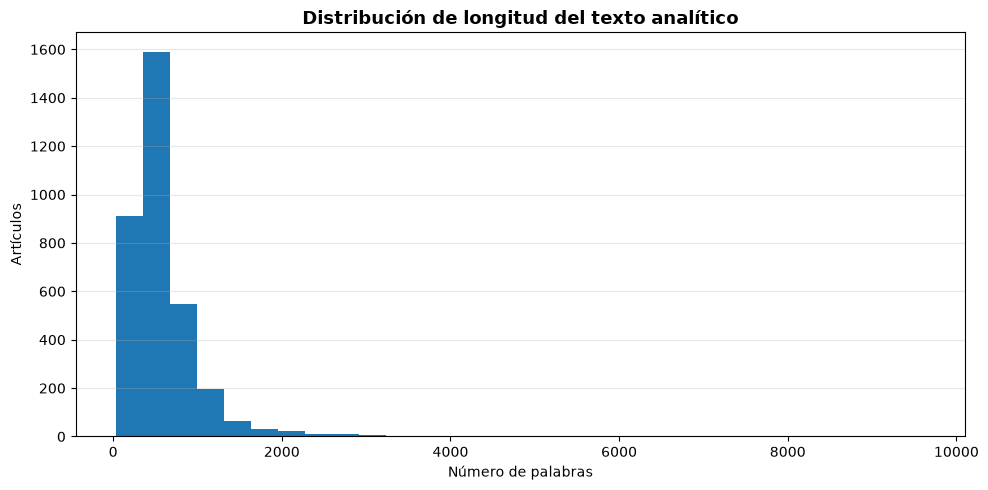

In [39]:
# ==========================================================
# Gráfico: distribución de longitud del texto analítico
# ==========================================================

lexical_length = lexical_cases.copy()
lexical_length["n_palabras"] = (
    lexical_length[TEXT_COL]
    .fillna("")
    .str.split()
    .str.len()
)

display(
    lexical_length["n_palabras"].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    lexical_length["n_palabras"],
    bins=30
)

ax.set_title(
    "Distribución de longitud del texto analítico",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Número de palabras")
ax.set_ylabel("Artículos")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Primera aproximación léxica

El objetivo de esta sección no es todavía interpretar marcos discursivos, sino obtener una base exploratoria reproducible:

- tamaño léxico del corpus;
- unigramas más frecuentes;
- bigramas y trigramas frecuentes;
- comparación Argentina–México mediante frecuencia normalizada;
- vocabulario distintivo mediante razón logarítmica suavizada.

Se usan reglas transparentes y locales, sin modelos externos.

In [40]:
def frequency_table_from_token_lists(token_lists, top_n=None):
    counter = Counter(chain.from_iterable(token_lists))
    total = sum(counter.values())

    out = pd.DataFrame(
        counter.items(),
        columns=["Termino", "Frecuencia"],
    ).sort_values(
        ["Frecuencia", "Termino"],
        ascending=[False, True],
    )

    out["Frecuencia_por_10k_tokens"] = (
        10000 * out["Frecuencia"] / total
        if total else 0
    )

    if top_n is not None:
        out = out.head(top_n)

    return out.reset_index(drop=True)


top_unigrams = frequency_table_from_token_lists(
    lexical_cases["tokens"],
    top_n=30,
)

display(top_unigrams)

,Termino,Frecuencia,Frecuencia_por_10k_tokens
0,mujeres,6600,64.88
1,años,6008,59.06
2,violencia,5486,53.92
3,mujer,4016,39.48
4,justicia,3664,36.02
5,había,3341,32.84
6,méxico,3162,31.08
7,estado,2918,28.68
8,quien,2872,28.23
9,género,2752,27.05


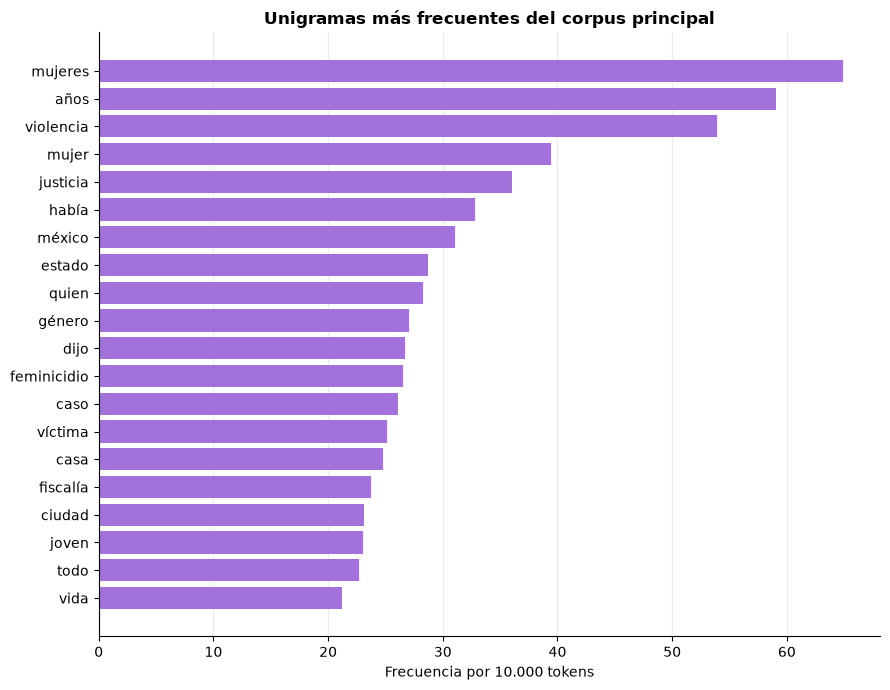

In [41]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_data = top_unigrams.head(20).sort_values(
    "Frecuencia_por_10k_tokens"
)

ax.barh(
    plot_data["Termino"],
    plot_data["Frecuencia_por_10k_tokens"],
    color=COLORS["violet_400"],
)

ax.set_title(
    "Unigramas más frecuentes del corpus principal",
    fontweight="bold",
)
ax.set_xlabel("Frecuencia por 10.000 tokens")
ax.set_ylabel("")
ax.grid(axis="x", color=COLORS["grid"], linewidth=0.8, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [42]:
# ==========================================================
# Bigramas y trigramas más frecuentes
# ==========================================================

# Bigramas
bigram_series = lexical_cases["tokens"].map(
    lambda tokens: make_ngrams(tokens, 2)
)

bigram_table = frequency_table_from_token_lists(
    bigram_series,
    top_n=30,
)

print("Top bigramas:")
display(bigram_table.head(20))


# Trigramas
trigram_series = lexical_cases["tokens"].map(
    lambda tokens: make_ngrams(tokens, 3)
)

trigram_table = frequency_table_from_token_lists(
    trigram_series,
    top_n=30,
)

print("Top trigramas:")
display(trigram_table.head(20))

Top bigramas:


,Termino,Frecuencia,Frecuencia_por_10k_tokens
0,violencia género,1420,14.00
1,ciudad méxico,1127,11.12
2,fiscalía general,746,7.36
3,derechos humanos,737,7.27
4,redes sociales,735,7.25
5,estado méxico,668,6.59
6,abuso sexual,604,5.96
7,violencia mujeres,519,5.12
8,general justicia,504,4.97
9,buenos aires,419,4.13


Top trigramas:


,Termino,Frecuencia,Frecuencia_por_10k_tokens
0,fiscalía general justicia,374,3.70
1,fiscalía general estado,243,2.40
2,manuel lópez obrador,180,1.78
3,andrés manuel lópez,179,1.77
4,día internacional mujer,169,1.67
5,general justicia estado,150,1.48
6,nacional seguridad pública,139,1.38
7,sistema nacional seguridad,137,1.36
8,justicia ciudad méxico,124,1.23
9,presidente andrés manuel,120,1.19


In [43]:
def plot_top_ngrams(
    df,
    term_col,
    freq_col,
    title,
    n=15
):
    plot_data = (
        df
        .nlargest(n, freq_col)
        .sort_values(freq_col)
    )

    fig, ax = plt.subplots(figsize=(9, 5.5))

    ax.barh(
        plot_data[term_col],
        plot_data[freq_col]
    )

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

    ax.grid(
        axis="x",
        alpha=0.3
    )

    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

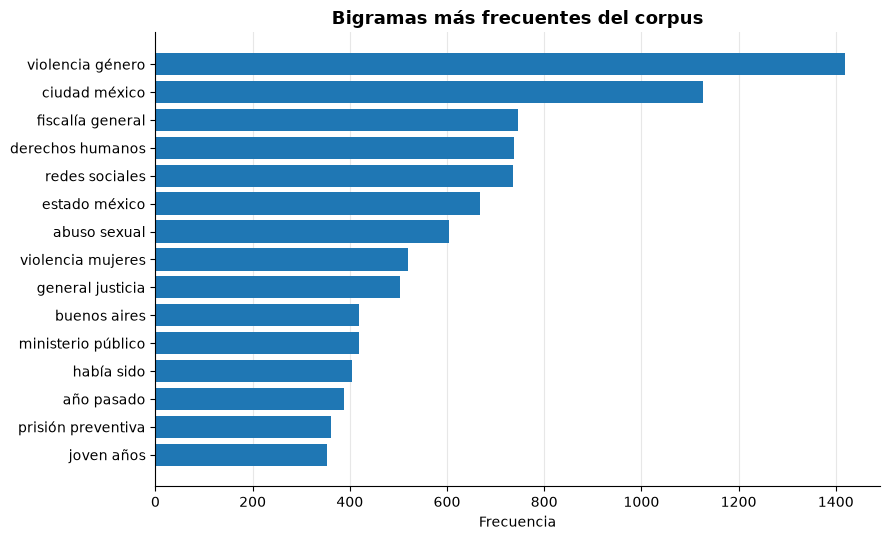

In [44]:
plot_top_ngrams(
    bigram_table,
    term_col="Termino",
    freq_col="Frecuencia",
    title="Bigramas más frecuentes del corpus"
)

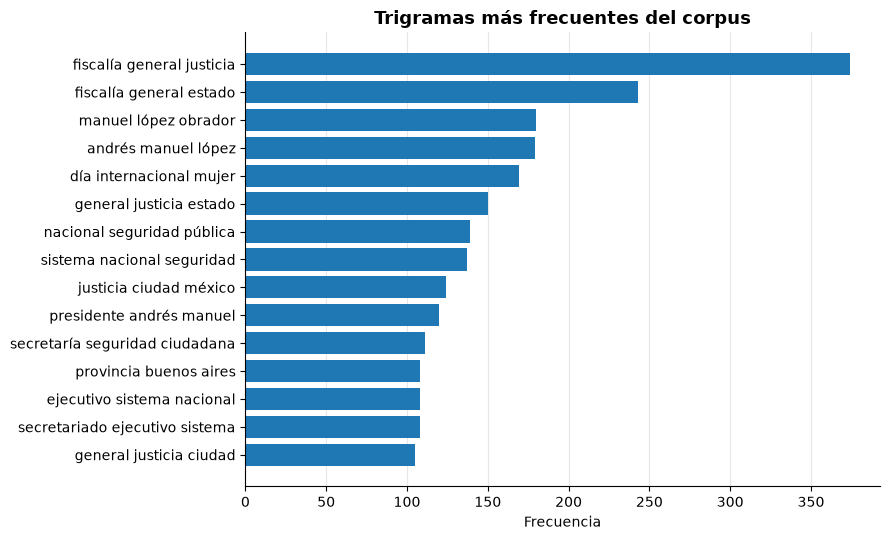

In [45]:
plot_top_ngrams(
    trigram_table,
    term_col="Termino",
    freq_col="Frecuencia",
    title="Trigramas más frecuentes del corpus"
)

In [46]:
bigram_tables_by_country = {}
trigram_tables_by_country = {}

for country in ["Argentina", "México"]:

    country_tokens = lexical_cases.loc[
        lexical_cases["country"].eq(country),
        "tokens"
    ]

    # Bigramas
    country_bigrams = country_tokens.map(
        lambda tokens: make_ngrams(tokens, 2)
    )

    bigram_tables_by_country[country] = (
        frequency_table_from_token_lists(
            country_bigrams,
            top_n=30,
        )
    )

    # Trigramas
    country_trigrams = country_tokens.map(
        lambda tokens: make_ngrams(tokens, 3)
    )

    trigram_tables_by_country[country] = (
        frequency_table_from_token_lists(
            country_trigrams,
            top_n=30,
        )
    )

In [47]:
display(
    bigram_tables_by_country["Argentina"].head(20)
)

,Termino,Frecuencia,Frecuencia_por_10k_tokens
0,violencia género,911,19.48
1,abuso sexual,428,9.15
2,buenos aires,410,8.77
3,había sido,294,6.29
4,emerenciano sena,287,6.14
5,cecilia strzyzowski,256,5.47
6,redes sociales,249,5.32
7,césar sena,230,4.92
8,marcela acuña,217,4.64
9,tenía años,216,4.62


In [48]:
display(
    bigram_tables_by_country["México"].head(20)
)

,Termino,Frecuencia,Frecuencia_por_10k_tokens
0,ciudad méxico,1111,20.34
1,fiscalía general,735,13.46
2,estado méxico,668,12.23
3,derechos humanos,614,11.24
4,violencia género,509,9.32
5,general justicia,503,9.21
6,redes sociales,486,8.90
7,violencia mujeres,416,7.62
8,años edad,336,6.15
9,delito feminicidio,332,6.08


### 9.1 Comparación léxica Argentina–México

In [49]:
country_frequency_tables = {}

for country in ["Argentina", "México"]:
    token_lists = lexical_cases.loc[
        lexical_cases["country"].eq(country),
        "tokens"
    ]
    country_frequency_tables[country] = (
        frequency_table_from_token_lists(token_lists)
    )

comparison = (
    country_frequency_tables["Argentina"][
        ["Termino", "Frecuencia", "Frecuencia_por_10k_tokens"]
    ]
    .rename(columns={
        "Frecuencia": "Frecuencia_Argentina",
        "Frecuencia_por_10k_tokens": "Por10k_Argentina",
    })
    .merge(
        country_frequency_tables["México"][
            ["Termino", "Frecuencia", "Frecuencia_por_10k_tokens"]
        ].rename(columns={
            "Frecuencia": "Frecuencia_Mexico",
            "Frecuencia_por_10k_tokens": "Por10k_Mexico",
        }),
        on="Termino",
        how="outer",
    )
    .fillna(0)
)

comparison["Frecuencia_total"] = (
    comparison["Frecuencia_Argentina"]
    + comparison["Frecuencia_Mexico"]
)

# Razón logarítmica suavizada sobre proporciones tokenizadas.
alpha = 0.5

total_arg = lexical_summary.loc[
    lexical_summary["country"].eq("Argentina"),
    "Tokens"
].sum()

total_mx = lexical_summary.loc[
    lexical_summary["country"].eq("México"),
    "Tokens"
].sum()

vocab_size = max(len(comparison), 1)

comparison["p_arg"] = (
    comparison["Frecuencia_Argentina"] + alpha
) / (
    total_arg + alpha * vocab_size
)

comparison["p_mx"] = (
    comparison["Frecuencia_Mexico"] + alpha
) / (
    total_mx + alpha * vocab_size
)

comparison["log2_ratio_arg_mx"] = np.log2(
    comparison["p_arg"] / comparison["p_mx"]
)

distinctive_terms = (
    comparison.loc[
        comparison["Frecuencia_total"] >= 20
    ]
    .sort_values("log2_ratio_arg_mx")
    .reset_index(drop=True)
)

print("Más asociados proporcionalmente a México:")
display(
    distinctive_terms[
        [
            "Termino",
            "Frecuencia_total",
            "Por10k_Argentina",
            "Por10k_Mexico",
            "log2_ratio_arg_mx",
        ]
    ].head(20)
)

print("Más asociados proporcionalmente a Argentina:")
display(
    distinctive_terms[
        [
            "Termino",
            "Frecuencia_total",
            "Por10k_Argentina",
            "Por10k_Mexico",
            "log2_ratio_arg_mx",
        ]
    ].tail(20).sort_values(
        "log2_ratio_arg_mx",
        ascending=False,
    )
)

Más asociados proporcionalmente a México:


,Termino,Frecuencia_total,Por10k_Argentina,Por10k_Mexico,log2_ratio_arg_mx
0,feminicida,495.00,0.00,9.03,-9.74
1,ariadna,230.00,0.00,4.19,-8.64
2,fofo,229.00,0.00,4.18,-8.63
3,cdmx,215.00,0.00,3.92,-8.54
4,fge,210.00,0.00,3.83,-8.50
5,chihuahua,203.00,0.00,3.70,-8.46
6,oaxaca,194.00,0.00,3.54,-8.39
7,cuauhtémoc,192.00,0.00,3.50,-8.38
8,guanajuato,183.00,0.00,3.34,-8.31
9,morelos,542.00,0.02,9.87,-8.28


Más asociados proporcionalmente a Argentina:


,Termino,Frecuencia_total,Por10k_Argentina,Por10k_Mexico,log2_ratio_arg_mx
6973,sena,992.00,21.15,0.00,11.17
6972,clarín,507.00,10.81,0.00,10.20
6971,emerenciano,486.00,10.36,0.00,10.14
6970,capitanich,356.00,7.59,0.00,9.69
6969,mirá,298.00,6.35,0.00,9.44
6968,strzyzowski,285.00,6.08,0.00,9.37
6967,provincial,273.00,5.82,0.00,9.31
6966,nacion,264.00,5.63,0.00,9.26
6965,farré,243.00,5.18,0.00,9.14
6964,femicida,227.00,4.84,0.00,9.04


In [50]:
# Top términos por país para comparación visual.
top_country_rows = []

for country in ["Argentina", "México"]:
    tmp = (
        country_frequency_tables[country]
        .head(20)
        .assign(country=country)
    )
    top_country_rows.append(tmp)

top_terms_by_country = pd.concat(
    top_country_rows,
    ignore_index=True,
)

display(top_terms_by_country)

,Termino,Frecuencia,Frecuencia_por_10k_tokens,country
0,años,3119,66.51,Argentina
1,había,2534,54.03,Argentina
2,violencia,2170,46.27,Argentina
3,mujer,2152,45.89,Argentina
4,casa,1895,40.41,Argentina
5,mujeres,1883,40.15,Argentina
6,femicidio,1650,35.18,Argentina
7,víctima,1506,32.11,Argentina
8,dijo,1456,31.05,Argentina
9,género,1425,30.39,Argentina


In [51]:
def plot_term_heatmap(
    data,
    country,
    terms,
    text_col=TEXT_COL,
    year_col="year"
):
    subset = data[
        data["country"] == country
    ].copy()

    rows = []

    for year, group in subset.groupby(year_col):

        texts = (
            group[text_col]
            .fillna("")
            .str.lower()
        )

        total_tokens = texts.str.split().str.len().sum()

        for term in terms:

            count = texts.str.count(
                rf"\b{re.escape(term)}\b"
            ).sum()

            normalized = (
                10000 * count / total_tokens
                if total_tokens > 0
                else 0
            )

            rows.append({
                "year": year,
                "term": term,
                "frequency": normalized
            })

    table = (
        pd.DataFrame(rows)
        .pivot(
            index="term",
            columns="year",
            values="frequency"
        )
        .fillna(0)
    )

    fig, ax = plt.subplots(
        figsize=(11, 0.55 * len(terms) + 2)
    )

    im = ax.imshow(
        table.values,
        aspect="auto"
    )

    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)

    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)

    ax.set_xlabel("Año")
    ax.set_ylabel("Término")

    ax.set_title(
        f"Evolución léxica en {country}\n"
        "Frecuencia por 10.000 tokens",
        fontweight="bold"
    )

    fig.colorbar(
        im,
        ax=ax,
        label="Frecuencia por 10.000 tokens"
    )

    plt.tight_layout()
    plt.show()

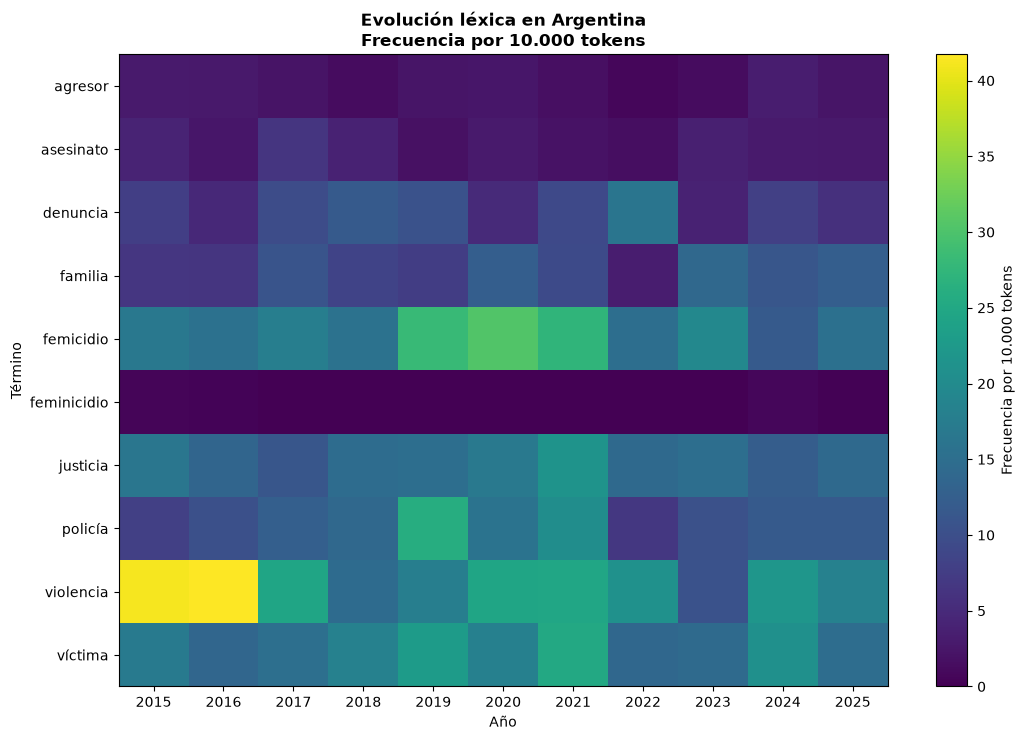

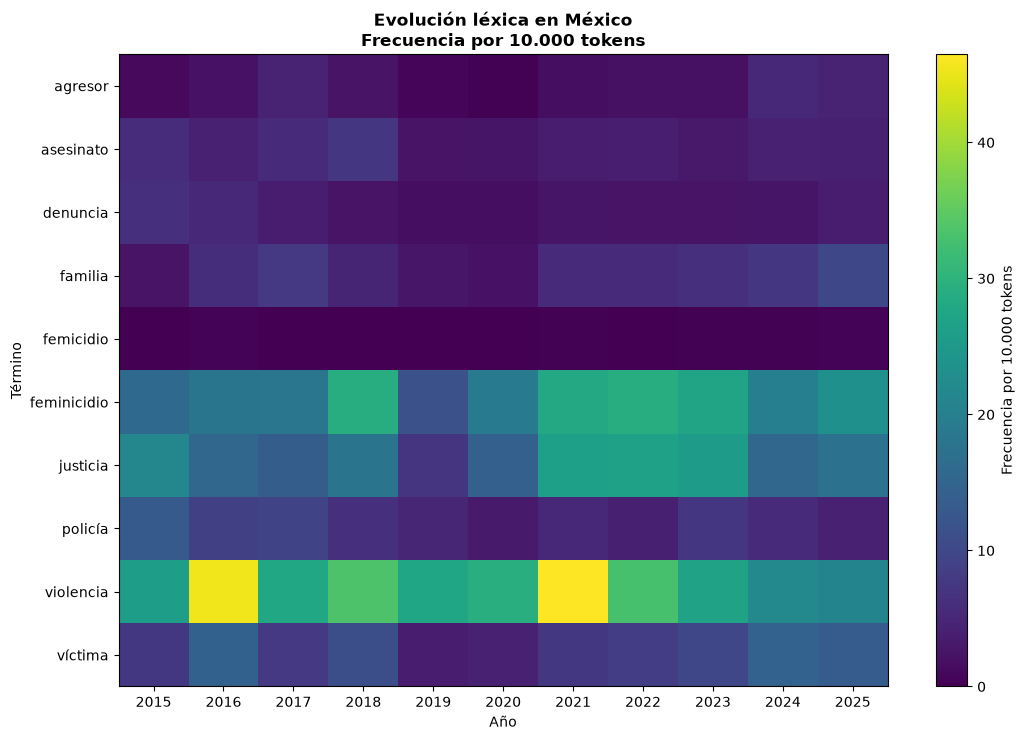

In [52]:
terms = [
    "femicidio",
    "feminicidio",
    "violencia",
    "víctima",
    "asesinato",
    "denuncia",
    "agresor",
    "justicia",
    "policía",
    "familia"
]

plot_term_heatmap(
    lexical_cases,
    "Argentina",
    terms
)

plot_term_heatmap(
    lexical_cases,
    "México",
    terms
)

### 9.2 Uso de femicidio/feminicidio

Como control descriptivo inicial se mide la presencia documental de ambas familias léxicas.  
Esto no sustituye la clasificación contextual: solo indica si la forma aparece en el texto.

In [53]:
LEXEME_PATTERNS = {
    "femicidio*": r"\bfemicid\w*",
    "feminicidio*": r"\bfeminicid\w*",
}

lexeme_rows = []

for label, pattern in LEXEME_PATTERNS.items():
    contains = (
        lexical_cases[TEXT_COL]
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
    )

    tmp = (
        lexical_cases.assign(_contains=contains)
        .groupby(["country", "year"], as_index=False)
        .agg(
            Noticias=(TEXT_COL, "size"),
            Noticias_con_termino=("_contains", "sum"),
        )
    )

    tmp["Porcentaje_documentos"] = (
        100
        * tmp["Noticias_con_termino"]
        / tmp["Noticias"]
    )
    tmp["Termino"] = label
    lexeme_rows.append(tmp)

lexeme_by_year_country = pd.concat(
    lexeme_rows,
    ignore_index=True,
)

display(lexeme_by_year_country)

,country,year,Noticias,Noticias_con_termino,Porcentaje_documentos,Termino
0,Argentina,2015,111,74,66.67,femicidio*
1,Argentina,2016,225,171,76.00,femicidio*
2,Argentina,2017,103,76,73.79,femicidio*
3,Argentina,2018,63,41,65.08,femicidio*
4,Argentina,2019,61,41,67.21,femicidio*
5,Argentina,2020,51,40,78.43,femicidio*
6,Argentina,2021,50,38,76.00,femicidio*
7,Argentina,2022,31,20,64.52,femicidio*
8,Argentina,2023,217,178,82.03,femicidio*
9,Argentina,2024,105,64,60.95,femicidio*


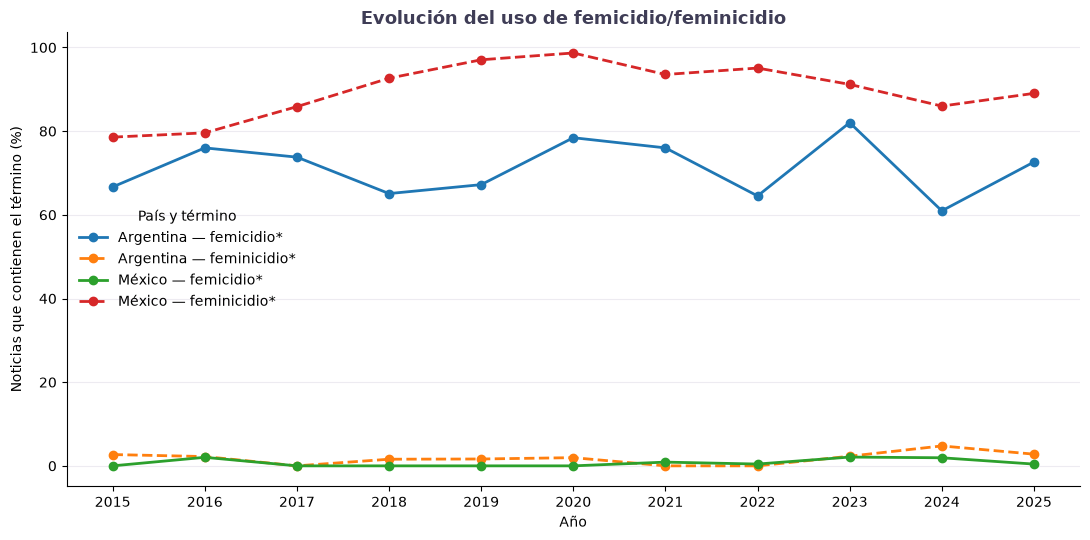

In [54]:
fig, ax = plt.subplots(figsize=(11, 5.5))

line_styles = {
    "femicidio*": "-",
    "feminicidio*": "--",
}

for (country, term), group in (
    lexeme_by_year_country
    .groupby(["country", "Termino"])
):

    group = group.sort_values("year")

    ax.plot(
        group["year"],
        group["Porcentaje_documentos"],
        marker="o",
        linestyle=line_styles[term],
        linewidth=2,
        label=f"{country} — {term}"
    )

ax.set_title(
    "Evolución del uso de femicidio/feminicidio",
    fontsize=13,
    fontweight="bold",
    color=COLORS["text"]
)

ax.set_xlabel("Año")

ax.set_ylabel(
    "Noticias que contienen el término (%)"
)

ax.grid(
    axis="y",
    color=COLORS["grid"],
    alpha=0.8
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    title="País y término"
)

years = sorted(
    lexeme_by_year_country["year"]
    .dropna()
    .unique()
)

ax.set_xticks(years)

plt.tight_layout()
plt.show()

In [55]:
# ==========================================================
# Evolución:
# femicidio/feminicidio explícito vs contextual
# ==========================================================

terminology_data = lexical_cases.copy()

CATEGORY_LABELS = {
    "Explícito": "Femicidio/feminicidio",
    "Contextual high": "Contextual",
}

# Total del corpus principal por país y año
# Incluye Topic en el denominador.
totals = (
    terminology_data
    .groupby(
        ["country", "year"],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Noticias_total"
        }
    )
)

# Solo categorías que queremos representar
terminology_counts = (
    terminology_data[
        terminology_data["final_category"]
        .isin(CATEGORY_LABELS.keys())
    ]
    .groupby(
        [
            "country",
            "year",
            "final_category"
        ],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Noticias"
        }
    )
)

terminology_counts["Categoria"] = (
    terminology_counts["final_category"]
    .map(CATEGORY_LABELS)
)

terminology_by_year = (
    terminology_counts
    .merge(
        totals,
        on=["country", "year"],
        how="left"
    )
)

terminology_by_year["Porcentaje"] = (
    100
    * terminology_by_year["Noticias"]
    / terminology_by_year["Noticias_total"]
)

display(terminology_by_year)

,country,year,final_category,Noticias,Categoria,Noticias_total,Porcentaje
0,Argentina,2015,Contextual high,26,Contextual,111,23.42
1,Argentina,2015,Explícito,73,Femicidio/feminicidio,111,65.77
2,Argentina,2016,Contextual high,35,Contextual,225,15.56
3,Argentina,2016,Explícito,176,Femicidio/feminicidio,225,78.22
4,Argentina,2017,Contextual high,16,Contextual,103,15.53
5,Argentina,2017,Explícito,78,Femicidio/feminicidio,103,75.73
6,Argentina,2018,Contextual high,14,Contextual,63,22.22
7,Argentina,2018,Explícito,43,Femicidio/feminicidio,63,68.25
8,Argentina,2019,Contextual high,13,Contextual,61,21.31
9,Argentina,2019,Explícito,42,Femicidio/feminicidio,61,68.85


In [56]:
from matplotlib.patches import Patch


def plot_explicit_vs_contextual(data):

    years = sorted(
        data["year"]
        .dropna()
        .unique()
    )

    countries = [
        "Argentina",
        "México",
    ]

    # Orden de apilamiento:
    # contextual abajo
    categories = [
        "Contextual",
        "Femicidio/feminicidio",
    ]

    category_colors = {
        "Contextual": COLORS.get(
            "violet_200",
            "#D8C5EF"
        ),
        "Femicidio/feminicidio": COLORS.get(
            "violet_600",
            "#7E3FC8"
        ),
    }

    # ------------------------------------------------------
    # Completar combinaciones ausentes con 0
    # ------------------------------------------------------

    full_index = pd.MultiIndex.from_product(
        [
            countries,
            years,
            categories,
        ],
        names=[
            "country",
            "year",
            "Categoria",
        ]
    )

    plot_data = (
        data
        .set_index(
            [
                "country",
                "year",
                "Categoria",
            ]
        )["Porcentaje"]
        .reindex(
            full_index,
            fill_value=0
        )
        .reset_index()
    )

    # ------------------------------------------------------
    # Posiciones
    # ------------------------------------------------------

    x = np.arange(len(years))
    width = 0.30

    positions = {
        "Argentina": x - width / 2,
        "México": x + width / 2,
    }

    fig, ax = plt.subplots(
        figsize=(13, 6.2)
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    totals_by_country = {}

    # ------------------------------------------------------
    # Barras
    # ------------------------------------------------------

    for country in countries:

        subset = plot_data[
            plot_data["country"] == country
        ]

        bottom = np.zeros(len(years))

        for category in categories:

            values = (
                subset[
                    subset["Categoria"] == category
                ]
                .set_index("year")
                .reindex(years)["Porcentaje"]
                .fillna(0)
                .to_numpy()
            )

            ax.bar(
                positions[country],
                values,
                width=width,
                bottom=bottom,
                color=category_colors[category],
                edgecolor="white",
                linewidth=0.8,
                zorder=3
            )

            bottom += values

        totals_by_country[country] = bottom

    # ------------------------------------------------------
    # Porcentaje total encima
    # ------------------------------------------------------

    max_total = max(
        totals_by_country["Argentina"].max(),
        totals_by_country["México"].max(),
        1
    )

    offset = max_total * 0.025

    for country in countries:

        for i, total in enumerate(
            totals_by_country[country]
        ):

            if total > 0:

                ax.text(
                    positions[country][i],
                    total + offset,
                    f"{total:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color=COLORS["text"]
                )

    # ------------------------------------------------------
    # AR / MX debajo
    # ------------------------------------------------------

    label_y = -max_total * 0.055

    for i in range(len(years)):

        ax.text(
            positions["Argentina"][i],
            label_y,
            "AR",
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COLORS["text"]
        )

        ax.text(
            positions["México"][i],
            label_y,
            "MX",
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COLORS["text"]
        )

    # ------------------------------------------------------
    # Estilo
    # ------------------------------------------------------

    ax.set_xticks(x)

    ax.set_xticklabels(
        [int(year) for year in years]
    )

    ax.set_xlabel(
        "Año",
        labelpad=22
    )

    ax.set_ylabel(
        "Porcentaje del corpus anual (%)"
    )

    ax.set_title(
        "Evolución del reconocimiento explícito y contextual",
        fontsize=13,
        fontweight="bold",
        color=COLORS["text"],
        pad=14
    )

    ax.grid(
        axis="y",
        color=COLORS["grid"],
        linewidth=0.8,
        alpha=0.8
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(
        -max_total * 0.09,
        max_total * 1.15
    )

    # ------------------------------------------------------
    # Leyenda
    # ------------------------------------------------------

    handles = [
        Patch(
            facecolor=category_colors["Contextual"],
            label="Contextual"
        ),
        Patch(
            facecolor=category_colors[
                "Femicidio/feminicidio"
            ],
            label="Femicidio/feminicidio"
        ),
    ]

    ax.legend(
        handles=handles,
        ncol=2,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.13)
    )

    fig.subplots_adjust(
        bottom=0.20
    )

    plt.show()

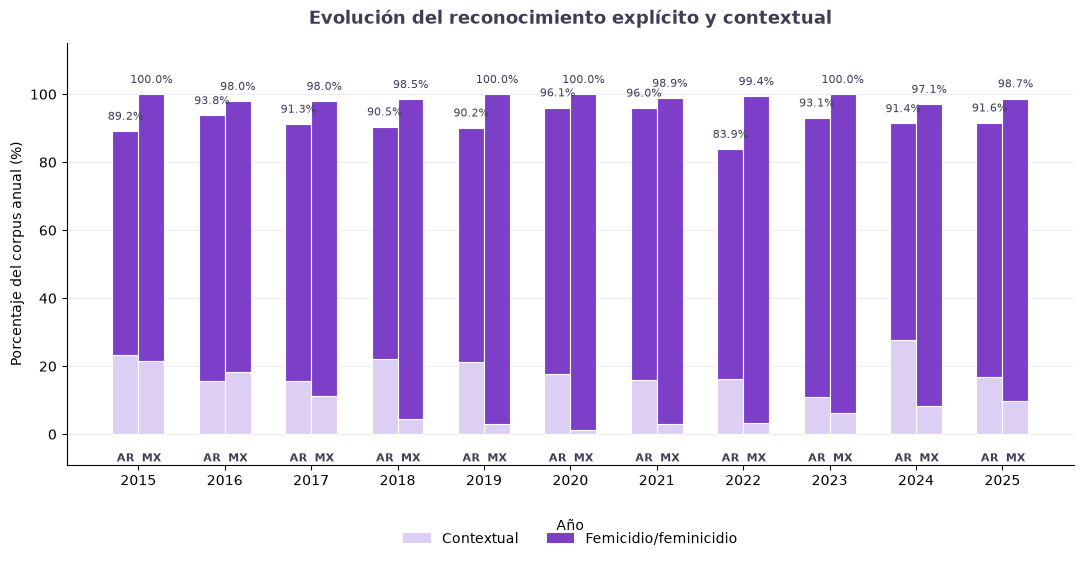

In [57]:
plot_explicit_vs_contextual(
    terminology_by_year
)

In [58]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt


def plot_explicit_vs_contextual(data):

    years = sorted(
        data["year"]
        .dropna()
        .unique()
    )

    countries = [
        "Argentina",
        "México",
    ]

    categories = [
        "Contextual",
        "Femicidio/feminicidio",
    ]

    # ======================================================
    # COLORES
    # claro = contextual
    # oscuro = término explícito
    # ======================================================

    COUNTRY_CATEGORY_COLORS = {
        "Argentina": {
            "Contextual": COLORS["argentina"],
            "Femicidio/feminicidio": "#2E3B83",
        },
        "México": {
            "Contextual": COLORS["mexico"],
            "Femicidio/feminicidio": COLORS["mexico_dark"],
        },
    }

    # ======================================================
    # COMPLETAR COMBINACIONES AUSENTES
    # ======================================================

    full_index = pd.MultiIndex.from_product(
        [
            countries,
            years,
            categories,
        ],
        names=[
            "country",
            "year",
            "Categoria",
        ]
    )

    plot_data = (
        data
        .set_index(
            [
                "country",
                "year",
                "Categoria",
            ]
        )["Porcentaje"]
        .reindex(
            full_index,
            fill_value=0
        )
        .reset_index()
    )

    # ======================================================
    # POSICIONES
    # ======================================================

    x = np.arange(len(years))
    width = 0.30

    positions = {
        "Argentina": x - width / 2,
        "México": x + width / 2,
    }

    fig, ax = plt.subplots(
        figsize=(13, 6.2)
    )

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    totals_by_country = {}

    # ======================================================
    # BARRAS
    # ======================================================

    for country in countries:

        subset = plot_data[
            plot_data["country"] == country
        ]

        bottom = np.zeros(len(years))

        for category in categories:

            values = (
                subset[
                    subset["Categoria"] == category
                ]
                .set_index("year")
                .reindex(years)["Porcentaje"]
                .fillna(0)
                .to_numpy()
            )

            ax.bar(
                positions[country],
                values,
                width=width,
                bottom=bottom,
                color=COUNTRY_CATEGORY_COLORS[
                    country
                ][category],
                edgecolor="white",
                linewidth=0.8,
                zorder=3
            )

            bottom += values

        totals_by_country[country] = bottom

    # ======================================================
    # PORCENTAJE TOTAL ENCIMA DE CADA BARRA
    # ======================================================

    max_total = max(
        totals_by_country["Argentina"].max(),
        totals_by_country["México"].max(),
        1
    )

    # ======================================================
    # EJE X
    # ======================================================
    ax.set_xticks(x)

    ax.set_xticklabels(
        [int(year) for year in years],
        fontsize=9
    )

    for i in range(len(years)):

        ax.text(
            positions["Argentina"][i],
            -0.055,
            "AR",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COLORS["text"],
            clip_on=False
        )

        ax.text(
            positions["México"][i],
            -0.055,
            "MX",
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8,
            fontweight="bold",
            color=COLORS["text"],
            clip_on=False
        )

    ax.set_xlabel(
        "Año",
        fontsize=10,
        color=COLORS["text"],
        labelpad=10
    )

    ax.set_ylabel(
        "Noticias según tipo de reconocimiento (%)",
        fontsize=10,
        color=COLORS["text"]
    )

    ax.set_title(
        "Evolución del reconocimiento explícito y contextual",
        fontsize=13,
        fontweight="bold",
        color=COLORS["text"],
        pad=22
    )

    # ======================================================
    # ESTILO
    # ======================================================

    ax.grid(
        axis="y",
        color=COLORS["grid"],
        linewidth=0.8,
        alpha=0.8
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(
        0,
        max_total * 1.15
    )

    # ======================================================
    # LEYENDA
    # ======================================================

    handles = [
        Patch(
            facecolor=COUNTRY_CATEGORY_COLORS[
                "Argentina"
            ]["Femicidio/feminicidio"],
            edgecolor="none",
            label="Argentina — Femicidio/feminicidio"
        ),
        Patch(
            facecolor=COUNTRY_CATEGORY_COLORS[
                "Argentina"
            ]["Contextual"],
            edgecolor="none",
            label="Argentina — Contextual"
        ),
        Patch(
            facecolor=COUNTRY_CATEGORY_COLORS[
                "México"
            ]["Femicidio/feminicidio"],
            edgecolor="none",
            label="México — Femicidio/feminicidio"
        ),
        Patch(
            facecolor=COUNTRY_CATEGORY_COLORS[
                "México"
            ]["Contextual"],
            edgecolor="none",
            label="México — Contextual"
        ),
    ]

    ax.legend(
        handles=handles,
        ncol=2,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.17),
        fontsize=9,
        columnspacing=1.8
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        top=0.90,
        bottom=0.24
    )

    plt.show()

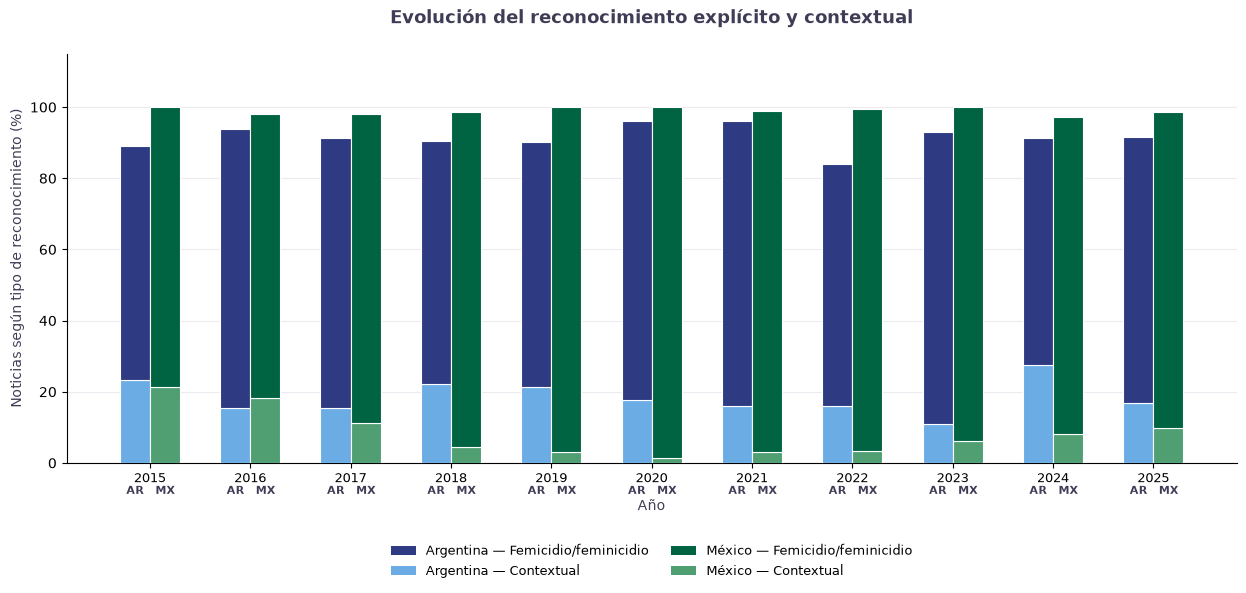

In [59]:
plot_explicit_vs_contextual(
    terminology_by_year
)

## 10. Preparación de corpus para IRaMuTeQ

La Fase 1 deja preparados también los corpus para IRaMuTeQ, pero **Argentina y México se exportan por separado** para no mezclar los dos universos nacionales. Cada documento conserva como variables suplementarias:

- año de captura;
- periódico;
- categoría analítica final.

El análisis de CHD, similitud y especificidades se realiza posteriormente en IRaMuTeQ sobre estos archivos.

In [60]:
def iramuteq_modality(value):
    value = str(value).strip().lower()
    replacements = {
        "á": "a", "é": "e", "í": "i",
        "ó": "o", "ú": "u", "ü": "u",
        "ñ": "n",
    }
    for old, new in replacements.items():
        value = value.replace(old, new)

    value = re.sub(r"[^a-z0-9]+", "_", value)
    return value.strip("_") or "na"


IRAMUTEQ_DIR = PHASE1_DIR / "iramuteq"
IRAMUTEQ_DIR.mkdir(parents=True, exist_ok=True)

iramuteq_exports = []

for country in ["Argentina", "México"]:
    subset = (
        analysis_cases.loc[
            analysis_cases["country"].eq(country)
            & analysis_cases["has_text"]
        ]
        .copy()
        .reset_index(drop=True)
    )

    output_path = (
        IRAMUTEQ_DIR
        / f"corpus_{iramuteq_modality(country)}.txt"
    )

    blocks = []

    for i, row in subset.iterrows():
        year = (
            int(row["year"])
            if pd.notna(row.get("year"))
            else "na"
        )

        header = (
            "**** "
            f"*id_{i + 1:05d} "
            f"*year_{year} "
            f"*source_{iramuteq_modality(row['source'])} "
            f"*newspaper_{iramuteq_modality(row['newspaper'])} "
            f"*category_{iramuteq_modality(row['final_category'])}"
        )

        text = re.sub(
            r"\s+",
            " ",
            str(row[TEXT_COL])
        ).strip()

        blocks.append(f"{header}\n{text}")

    output_path.write_text(
        "\n\n".join(blocks),
        encoding="utf-8",
    )

    iramuteq_exports.append({
        "country": country,
        "documents": len(subset),
        "path": str(output_path.relative_to(ROOT)),
    })

iramuteq_export_summary = pd.DataFrame(
    iramuteq_exports
)

display(iramuteq_export_summary)

,country,documents,path
0,Argentina,1196,outputs\reports\phase1\iramuteq\corpus_argenti...
1,México,2204,outputs\reports\phase1\iramuteq\corpus_mexico.txt


## 11. Exportación de resultados reproducibles

In [63]:
outputs_to_save = {
    "coverage_by_year_source.csv": coverage_by_year_source,
    "preselection_country.csv": preselection_country,
    "preselection_newspaper.csv": preselection_newspaper,
    "final_selection_summary.csv": final_selection_summary,
    "corpus_by_country.csv": corpus_by_country,
    "corpus_by_newspaper.csv": corpus_by_newspaper,
    "corpus_by_year_country_source.csv": corpus_by_year_country_source,
    "corpus_by_year_country_category.csv": final_category_year_country,
    "text_quality_by_group.csv": text_quality_by_group,
    "lexical_top_unigrams.csv": top_unigrams,
    "lexical_distinctive_argentina_mexico.csv": distinctive_terms,
    "lexeme_femicidio_feminicidio_by_year_country.csv": lexeme_by_year_country,
}

# ----------------------------------------------------------
# N-gramas por país
# ----------------------------------------------------------

for country in ["Argentina", "México"]:

    country_slug = (
        country.lower()
        .replace("é", "e")
    )

    outputs_to_save[
        f"lexical_top_bigrams_{country_slug}.csv"
    ] = bigram_tables_by_country[country]

    outputs_to_save[
        f"lexical_top_trigrams_{country_slug}.csv"
    ] = trigram_tables_by_country[country]


# ----------------------------------------------------------
# Guardado
# ----------------------------------------------------------

PHASE1_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for filename, df in outputs_to_save.items():

    path = PHASE1_DIR / filename

    df.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
    )


print(
    f"Se guardaron {len(outputs_to_save)} "
    f"tablas en {PHASE1_DIR}"
)

Se guardaron 16 tablas en C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\outputs\reports\phase1


## 12. Controles finales de la Fase 1

La fase se considera técnicamente cerrada si se cumplen los controles siguientes:

- el resumen de extracción reconcilia;
- existe un universo único evaluable;
- la preselección es subconjunto del universo evaluable;
- los destinos finales son disjuntos;
- preselección = corpus principal + sensibilidad + ambiguos + exclusiones;
- todas las noticias del corpus principal tienen una categoría analítica reconocida;
- los recuentos por país y periódico suman el corpus principal;
- el análisis léxico se ejecuta únicamente sobre noticias con texto no vacío.

In [62]:
checks = {
    "Extracción reconcilia": (
        total_valid + total_invalid == processed_total
    ),
    "Preselección dentro del universo evaluable": (
        len(preselected_cases) <= len(contextual_valid)
    ),
    "Destinos finales disjuntos": (
        main_set.isdisjoint(medium_set)
        and main_set.isdisjoint(ambiguous_set)
        and medium_set.isdisjoint(ambiguous_set)
    ),
    "Preselección reconcilia con destinos": (
        final_selection_summary["Noticias"].sum()
        == len(preselected_cases)
    ),
    "Categorías finales completas": (
        analysis_cases["final_category"]
        .notna()
        .all()
    ),
    "Países suman corpus principal": (
        corpus_by_country["Noticias"].sum()
        == len(analysis_cases)
    ),
    "Periódicos suman corpus principal": (
        corpus_by_newspaper["Noticias"].sum()
        == len(analysis_cases)
    ),
    "Corpus léxico sin textos vacíos": (
        lexical_cases[TEXT_COL].str.strip().ne("").all()
    ),
}

check_table = pd.DataFrame({
    "Control": checks.keys(),
    "Correcto": checks.values(),
})

display(check_table)

if not all(checks.values()):
    failed = [
        name for name, ok in checks.items()
        if not ok
    ]
    raise AssertionError(
        "Hay controles pendientes:\n- "
        + "\n- ".join(failed)
    )

print("Fase 1 completada: todos los controles son correctos.")

,Control,Correcto
0,Extracción reconcilia,True
1,Preselección dentro del universo evaluable,True
2,Destinos finales disjuntos,True
3,Preselección reconcilia con destinos,True
4,Categorías finales completas,True
5,Países suman corpus principal,True
6,Periódicos suman corpus principal,True
7,Corpus léxico sin textos vacíos,True


Fase 1 completada: todos los controles son correctos.
